Home Default Analysis EDA
- Examine Data

Three sections:  
&nbsp;&nbsp;&nbsp;&nbsp;a) build merged data  
&nbsp;&nbsp;&nbsp;&nbsp;b) distribution stretching   
&nbsp;&nbsp;&nbsp;&nbsp;c) inference  


git home-credit-default-risk -p "E:\Education\Github\home-credit"
data dir "E:\Education\Github\home-credit\data" 

<div class="alert alert-block alert-info">
    <p>
    <b><font size="5">Build Conda Env (home-credit)</font>
    </b></p>
    <p>
        A conda env (home-credit) was built using python=3.11<br>
        The following packages were installed as well:<br>
        &nbsp;&nbsp;&nbsp;&nbsp;ipywidgets, opt_einsum, pgmpy, pandas, numpy, 
                                scikit-learn, pyro-ppl, maptplotlib, seaborn.
    </p>    
</div>


<div class="alert alert-block alert-info">
    <p>
    <b><font size="5">Phase 1 Code — Build and Fit the Network</font>
    </b></p>
</div>

In [1]:
import sys
sys.path.append(r'E:/Education/Github\home-loan-default/src')
import pandas as pd
import numpy as np
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import (HillClimbSearch, BayesianEstimator, MaximumLikelihoodEstimator, PC, ExpertKnowledge)
from pgmpy.inference import VariableElimination
from sklearn.preprocessing import KBinsDiscretizer
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pgmpy.models import DiscreteBayesianNetwork
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, ConfusionMatrixDisplay, f1_score, recall_score, precision_score)
from sklearn.model_selection import train_test_split
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)
import networkx as nx
from datetime import datetime
import graph_structure_discovery as gsd

<div class="alert alert-block alert-info">
    <b><font size="5">LOAD &amp; PREP DATA</font></b>
    <ul>
        <li>a) Using Home Credit main table as our starting point</li>
        <li>b) Download from: <a href="https://www.kaggle.com/c/home-credit-default-risk/data">https://www.kaggle.com/c/home-credit-default-risk/data</a></li>
        <li>c) CSV files are in data directory</li>
    </ul>
    <img src="images/home_credit.png" width="600">
</div>

In [131]:
#setup logging
def setup_logging(level):
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    log_file  = f'logs/bayesian_model_{timestamp}.log'

    # Get root logger and set level
    root_logger = logging.getLogger()
    root_logger.setLevel(level)

    # Remove any existing file handlers to avoid duplicate log files
    root_logger.handlers = [
        h for h in root_logger.handlers 
        if not isinstance(h, logging.FileHandler)
    ]

    # Add fresh file handler
    fh = logging.FileHandler(log_file, mode='a', encoding='utf-8')
    fh.setLevel(level)
    fh.setFormatter(logging.Formatter(
        fmt='%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
    root_logger.addHandler(fh)

    logger = logging.getLogger(__name__)
    logger.debug(f"Logger initialized — level: {logging.getLevelName(level)}, file: {log_file}")

    return logger

In [11]:
data_dir = "data/"
table_keys   = pd.read_csv(f"{data_dir}\\home_credit_keys.csv")                           

def get_df_info(df_name, df):
    """Returns a DataFrame with column names and data types for a given dataframe."""
    return pd.DataFrame({
        'df_name':       df_name,
        'df_column':     df.columns,
        'col_data_type': df.dtypes.values
    })


In [12]:
# capture Relationships between dataframes
#table_keys['table'] = table_keys['table'].str.lower()
#table_keys.sort_values(
#    by=['table', 'pk'],
#    ascending=[True, False]
#)

#pk_keys = table_keys[table_keys['pk'] == 'Y']
#all_keys = table_keys

fk_mapping = table_keys.merge(
    table_keys[table_keys['pk'] == 'Y'][['column', 'table']],
    on='column',
    how='left',
    suffixes=('_fk_table', '_pk_table')
)

fk_mapping['table_pk_table'] = fk_mapping['table_pk_table'].fillna('')

(fk_mapping[['table_fk_table', 'column', 'pk', 'fk', 'table_pk_table']]
            .sort_values(by=['table_fk_table', 'pk'], ascending=[True, False]))


,table_fk_table,column,pk,fk,table_pk_table
0,application_train,SK_ID_CURR,Y,N,application_train
1,bureau,SK_ID_BUREAU,Y,N,bureau
2,bureau,SK_ID_BUREAU,Y,N,bureau_balance
3,bureau,SK_ID_CURR,N,Y,application_train
4,bureau_balance,SK_ID_BUREAU,Y,Y,bureau
5,bureau_balance,SK_ID_BUREAU,Y,Y,bureau_balance
6,bureau_balance,MONTHS_BALANCE,Y,N,bureau_balance
7,bureau_balance,MONTHS_BALANCE,Y,N,pos_cash_balance
8,bureau_balance,MONTHS_BALANCE,Y,N,credit_card_balance
28,credit_card_balance,SK_ID_PREV,Y,Y,previous_application


In [13]:
# create pivot display with columns (table names) and rows (table columns)
pivot = pd.DataFrame({
    name: pd.Series(df.columns.tolist()) for name, df in dfs.items() if name != 'application_train'
}).fillna('')
pivot.index = pivot.index + 1  # start row numbers at 1 instead of 0

pivot.style.set_properties(**{'font-size': '6pt'})

,bureau,bureau_balance,previous_application,installments_payments,pos_cash_balance,credit_card_balance
1,SK_ID_CURR,SK_ID_BUREAU,SK_ID_PREV,SK_ID_PREV,SK_ID_PREV,SK_ID_PREV
2,SK_ID_BUREAU,MONTHS_BALANCE,SK_ID_CURR,SK_ID_CURR,SK_ID_CURR,SK_ID_CURR
3,CREDIT_ACTIVE,STATUS,NAME_CONTRACT_TYPE,NUM_INSTALMENT_VERSION,MONTHS_BALANCE,MONTHS_BALANCE
4,CREDIT_CURRENCY,,AMT_ANNUITY,NUM_INSTALMENT_NUMBER,CNT_INSTALMENT,AMT_BALANCE
5,DAYS_CREDIT,,AMT_APPLICATION,DAYS_INSTALMENT,CNT_INSTALMENT_FUTURE,AMT_CREDIT_LIMIT_ACTUAL
6,CREDIT_DAY_OVERDUE,,AMT_CREDIT,DAYS_ENTRY_PAYMENT,NAME_CONTRACT_STATUS,AMT_DRAWINGS_ATM_CURRENT
7,DAYS_CREDIT_ENDDATE,,AMT_DOWN_PAYMENT,AMT_INSTALMENT,SK_DPD,AMT_DRAWINGS_CURRENT
8,DAYS_ENDDATE_FACT,,AMT_GOODS_PRICE,AMT_PAYMENT,SK_DPD_DEF,AMT_DRAWINGS_OTHER_CURRENT
9,AMT_CREDIT_MAX_OVERDUE,,WEEKDAY_APPR_PROCESS_START,,,AMT_DRAWINGS_POS_CURRENT
10,CNT_CREDIT_PROLONG,,HOUR_APPR_PROCESS_START,,,AMT_INST_MIN_REGULARITY


In [14]:
# Print data and data types for a particular dataframe 
summary[summary['df_name'] == 'installments_payments']

,df_name,df_column,col_data_type
179,installments_payments,SK_ID_PREV,int64
180,installments_payments,SK_ID_CURR,int64
181,installments_payments,NUM_INSTALMENT_VERSION,float64
182,installments_payments,NUM_INSTALMENT_NUMBER,int64
183,installments_payments,DAYS_INSTALMENT,float64
184,installments_payments,DAYS_ENTRY_PAYMENT,float64
185,installments_payments,AMT_INSTALMENT,float64
186,installments_payments,AMT_PAYMENT,float64


In [15]:
# Print table name, data types and descriptioins for a particular dataframe
data_dict = pd.read_csv(f"{data_dir}\\HomeCredit_columns_description.csv", encoding='latin-1', index_col=0)
data_dict = data_dict.rename(columns={'Row': 'Table_Column'})
data_dict = data_dict[~data_dict['Table'].isin(['application_{train|test}.csv'])]
data_dict['Table'] = data_dict['Table'].str.replace('.csv', '', regex=False)
data_dict[data_dict['Table'] == 'installments_payments']

,Table,Table_Column,Description,Special
214,installments_payments,SK_ID_PREV,ID of previous credit in Home credit related t...,hashed
215,installments_payments,SK_ID_CURR,ID of loan in our sample,hashed
216,installments_payments,NUM_INSTALMENT_VERSION,Version of installment calendar (0 is for cred...,NaN
217,installments_payments,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN
218,installments_payments,DAYS_INSTALMENT,When the installment of previous credit was su...,time only relative to the application
219,installments_payments,DAYS_ENTRY_PAYMENT,When was the installments of previous credit p...,time only relative to the application
220,installments_payments,AMT_INSTALMENT,What was the prescribed installment amount of ...,NaN
221,installments_payments,AMT_PAYMENT,What the client actually paid on previous cred...,NaN


#Distribution Stretching 


In [16]:
def plot_continuous_by_outcome(summary_df, col, app_train, logger, bins=50):
    """
    Plot overlapping histograms of a raw continuous column
    split by LoanOutcome — shows exactly where the distributions diverge.
    """
    labeled = app_train[['SK_ID_CURR', 'TARGET']].copy()
    labeled['LoanOutcome'] = np.where(labeled['TARGET'] == 0, 'Repaid', 'Defaulted')
    
    diag = summary_df[['SK_ID_CURR', col]].merge(labeled, on='SK_ID_CURR')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left — overlapping histograms
    for outcome, color in [('Repaid', 'steelblue'), ('Defaulted', 'tomato')]:
        subset = diag[diag['LoanOutcome'] == outcome][col].dropna()
        axes[0].hist(subset, bins=bins, alpha=0.5, color=color,
                     label=outcome, density=True)
    axes[0].set_title(f'{col} — distribution by outcome')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Density')
    axes[0].legend()
    
    # Right — default rate by percentile bucket
    # This shows WHERE along the range defaults concentrate
    diag['percentile_bin'] = pd.qcut(diag[col], q=10, 
                                      duplicates='drop', labels=False)
    rate_by_bin = diag.groupby('percentile_bin').apply(
        lambda x: pd.Series({
            'default_rate': (x['LoanOutcome'] == 'Defaulted').mean(),
            'count':        len(x),
            'bin_midpoint': x[col].median()
        })
    ).reset_index()
    
    axes[1].bar(rate_by_bin['bin_midpoint'], rate_by_bin['default_rate'],
                width=rate_by_bin['bin_midpoint'].diff().median() * 0.8,
                color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].axhline(y=diag['LoanOutcome'].eq('Defaulted').mean(),
                    color='red', linestyle='--', label='Overall default rate')
    axes[1].set_title(f'{col} — default rate by decile')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Default rate')
    axes[1].legend()
    
    plt.suptitle(f'EDA: {col}', fontsize=13)
    plt.tight_layout()
    
    Path('logs').mkdir(exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    plot_path = f'logs/eda_{col}_{ts}.png'
    plt.savefig(plot_path)
    plt.close()
    logger.debug(f"EDA plot saved: {plot_path}")
    return rate_by_bin

In [29]:
def plot_fill_summary(fill_summary):

    (fill_summary.groupby('on_time_rate')
                 .size().reset_index(name='count')
                 .sort_values('count', ascending=False).head(10)
    ) 

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram with KDE
    sns.histplot(fill_summary[fill_summary['on_time_rate'] < 1]['on_time_rate'], kde=True, ax=axes[0])
    axes[0].set_title('On-Time Rate Distribution for rate < 100%')
    axes[0].set_xlabel('on_time_rate')

    # Q-Q plot to check normality
    stats.probplot(fill_summary['on_time_rate'].dropna(), plot=axes[1])
    axes[1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()
    return

In [30]:
# Payment on_time_rate and Payment History. Were recent installments paid on time? 
# Analogous to PriorFills in Pre-Auth
# (analog: did member fill prior prescriptions as expected?)

def generate_install_summary(data_dir, logger):
    
    logger.debug(f"Running generate_install_summary dir: {data_dir}")
    
    
    install      = pd.read_csv(f"{data_dir}\\installments_payments.csv")
        
    fill_summary = install.groupby('SK_ID_CURR').apply(
        lambda x: pd.Series({
            'on_time_rate': (x['DAYS_ENTRY_PAYMENT'] <= x['DAYS_INSTALMENT']).mean(),
            'total_fills':  len(x)
        })
        ).reset_index()

    # Bucket on_time_rate into categorical PaymentHistory
    fill_summary['PaymentHistory'] = pd.cut(
            fill_summary['on_time_rate'],
            bins=[0, 0.5, 0.8, 1.01],
            labels=['Low', 'Medium', 'High']
        )
    
    plot_fill_summary(fill_summary)
    logger.debug(f"table: fill_summary, rows: {fill_summary.shape[0]}, cols: {fill_summary.shape[1]}")
    return fill_summary


In [74]:
# Add Credit Utilization
def generate_util_summary(data_dir, logger):
    
    logger.debug(f"Running generate_util_summary dir: {data_dir}")
    
    credit_card  = pd.read_csv(f"{data_dir}\\credit_card_balance.csv")
    
    credit_card['CREDIT_UTILIZATION'] = np.where(
    credit_card['AMT_CREDIT_LIMIT_ACTUAL'] > 0,
    credit_card['AMT_BALANCE'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL'], 0 )

    util_summary = credit_card.groupby('SK_ID_CURR').agg(
                        avg_utilization = ('CREDIT_UTILIZATION', 'mean'),
                        max_utilization = ('CREDIT_UTILIZATION', 'max')
                    ).reset_index()

    util_summary['CreditUtilization'] = pd.cut(
                        util_summary['avg_utilization'],
                        bins=[-0.061, 0.45, 3.0, 999],
                        labels=['Low', 'Medium', 'High']
                    )
    
    logger.debug(f"table: util_summary, rows: {util_summary.shape[0]}, cols: {util_summary.shape[1]}")
                    
    return util_summary

In [24]:
# Add Positive Cash
def generate_pos_summary(data_dir,logger):
    
    logger.debug(f"Running generate_pos_summary dir: {data_dir}")
    
    pos_cash     = pd.read_csv(f"{data_dir}\\POS_CASH_balance.csv")
    

    pos_summary = pos_cash.groupby('SK_ID_CURR').agg(
                      max_dpd          = ('SK_DPD',               'max'),
                      max_dpd_def      = ('SK_DPD_DEF',           'max'),
                      active_contracts = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum())
                  ).reset_index()

    pos_summary['DPD'] = pd.cut(
                            pos_summary['max_dpd'],
                            bins=[-1, 0, 30, 60, 999999],
                            labels=['None', 'Low', 'Medium', 'High']
                         )

    pos_summary['ContractStatus'] = np.where(pos_summary['active_contracts'] > 0, 'Active', 'Inactive')
    logger.debug(f"table: pos_summary, rows: {pos_summary.shape[0]}, cols: {pos_summary.shape[1]}")
                 
    return pos_summary

In [25]:
# Add bureau data
# bureau → bureau_summary

def generate_bureau_summary(data_dir, logger):
    
    logger.debug(f"Running generate_bureau_summary dir: {data_dir}")
    
    bureau       = pd.read_csv(f"{data_dir}\\bureau.csv")
    
    bureau_summary = bureau.groupby('SK_ID_CURR').agg(
                        max_days_overdue = ('CREDIT_DAY_OVERDUE',    'max'),
                        max_overdue_amt  = ('AMT_CREDIT_MAX_OVERDUE', 'max'),
                        total_debt       = ('AMT_CREDIT_SUM_DEBT',    'sum'),
                        total_prolonged  = ('CNT_CREDIT_PROLONG',     'sum'),
                        active_credits   = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum())
                    ).reset_index()

    bureau_summary['DaysOverdue'] = pd.cut(
                                        bureau_summary['max_days_overdue'],
                                        bins=[-1, 0, 30, 90, 999999],
                                        labels=['None', 'Low', 'Medium', 'High']
                                    )
            
    bureau_summary['MaxOverdue'] = pd.cut(
                                        bureau_summary['max_overdue_amt'],
                                        bins=[-1, 0, 1000, 10000, 999999999],
                                        labels=['None', 'Low', 'Medium', 'High']
                                    )
    
    bureau_summary['DebtLoad'] = pd.cut(
                                        bureau_summary['total_debt'],
                                        bins=[-1, 0, 50000, 200000, 999999999],
                                        labels=['None', 'Low', 'Medium', 'High']
                                )
    
    bureau_summary['CreditProlonged'] = pd.cut(
                                            bureau_summary['total_prolonged'],
                                            bins=[-1, 0, 1, 3, 999],
                                            labels=['Never', 'Once', 'Several', 'Many']
                                        )
    
    bureau_summary['ActiveCredits'] = pd.cut(
                                        bureau_summary['active_credits'],
                                        bins=[-1, 0, 1, 3, 999],
                                        labels=['None', 'One', 'Few', 'Many']
                                      )

    logger.debug(f"table: bureau_summary, rows: {bureau_summary.shape[0]}, cols: {bureau_summary.shape[1]}")
    return bureau_summary


In [26]:
#prev_app → prev_summary

def generate_prev_summary(data_dir, logger):
    
    logger.debug(f"Running generate_prev_summary dir: {data_dir}")
    
    prev_app     = pd.read_csv(f"{data_dir}\\previous_application.csv")

    prev_summary = prev_app.groupby('SK_ID_CURR').agg(
                        prior_approved = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
                        prior_refused  = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
                        prior_total    = ('NAME_CONTRACT_STATUS', 'count')
                    ).reset_index()
    
    prev_summary['PriorLoanApproved'] = np.where(prev_summary['prior_approved'] > 0, 'Yes', 'No')

    prev_summary['PrevRejected'] = pd.cut(
                prev_summary['prior_refused'],
                bins=[-1, 0, 1, 2, 999999],   # ← safer upper bound
                labels=['None', 'Once', 'Twice', 'Multiple']
    )
    logger.debug(f"table: prev_summary, rows: {prev_summary.shape[0]}, cols: {prev_summary.shape[1]}")
    return prev_summary   

In [103]:
def get_app_data2(data_dir, logger):
    
    logger.debug(f"Running get_app_data dir: {data_dir}")
    
    app_train  = pd.read_csv(f"{data_dir}\\application_train.csv")
    app_test   = pd.read_csv(f"{data_dir}\\application_test.csv")
    app_data   = pd.concat([app_train, app_test], ignore_index=True)
    
    # IncomeType: is the applicant's income from a stable source?
    # (analog: is the diagnosis code consistent with the drug requested?)
    new_cols = pd.DataFrame({
                    'IncomeType': np.where(
                        app_data['NAME_INCOME_TYPE'].isin(['Working', 'Commercial associate']),
                            'Stable', 'Unstable'
                ),
                    'OccupationType': np.where(
                        app_data['OCCUPATION_TYPE'].isna(), 'Unknown', np.where(
                                app_data['OCCUPATION_TYPE'].isin(['Managers', 'Core staff',
                                                                   'High skill tech staff',
                                                                   'Medicine staff', 'Accountants']),
                                                                    'Professional', 'Laborer'
                                                                 )
                ),
                        'IncomeBracket': pd.qcut(app_data['AMT_INCOME_TOTAL'], q=3, labels=['Low', 'Medium', 'High']
                ),
                        'LoanOutcome': np.where(app_data['TARGET'] == 0, 'Repaid', 'Defaulted')
                ,
                        'ExtSource1Risk': pd.cut(app_data['EXT_SOURCE_1'],
                                                  bins  = [0, 0.2, 0.35, 0.5, 0.65, 0.8, 1.01],
                                                  labels= ['VeryHigh', 'High', 'MedHigh', 'Medium', 'Low', 'VeryLow']),

                        'ExtSource2Risk': pd.cut(app_data['EXT_SOURCE_2'],
                                                  bins  = [0, 0.2, 0.35, 0.5, 0.65, 0.8, 1.01],
                                                  labels= ['VeryHigh', 'High', 'MedHigh', 'Medium', 'Low', 'VeryLow']),

                        'ExtSource3Risk': pd.cut(app_data['EXT_SOURCE_3'],
                                                  bins  = [0, 0.2, 0.35, 0.5, 0.65, 0.8, 1.01],
                                                  labels= ['VeryHigh', 'High', 'MedHigh', 'Medium', 'Low', 'VeryLow']),

                        'AmtCredit': pd.cut(app_data['AMT_CREDIT'],
                                                  bins  = [0, 252000, 270000, 675000, 1125000, 1350000, 4100000],
                                                  labels= ['MedHigh', 'Med', 'High', 'MedLow', 'VeryLow', 'Low']),

                        'AmtGoodsPrice': pd.cut(app_data['AMT_GOODS_PRICE'],
                                                  bins  = [0, 171000, 270000, 450000, 454500, 675000, 4100000],
                                                  labels= ['High', 'Medium', 'VeryHigh', 'Low', 'MedHigh', 'VeryLow']),

                        'AmtReqCreditBureauMon': pd.cut(app_data['AMT_REQ_CREDIT_BUREAU_MON'],
                                                  bins  = [0, 1, 27],
                                                  labels= ['Medium', 'VeryLow']),                                                                              
    }, index=app_data.index)
    
    temp_df = pd.concat([app_data, new_cols], axis=1).copy()
     
    
    # Summary Counts
    logger.debug(f"IncomeBracket distribution:\n{temp_df['IncomeBracket'].value_counts(dropna=False).to_string()}")
    logger.debug(f"LoanOutcome distribution:\n{temp_df['LoanOutcome'].value_counts(dropna=False).to_string()}")
    for col in ['ExtSource1Risk', 'ExtSource2Risk', 'ExtSource3Risk', 'AmtCredit', 'AmtGoodsPrice', 'AmtReqCreditBureauMon']:
        logger.debug(f"{col} distribution:\n"
                     f"{temp_df[col].value_counts(dropna=False).to_string()}")

    return temp_df

**The key principle — all feature engineering happens BEFORE `main()`:**
```
Raw tables
    ↓
Summary tables (fill_summary, util_summary, prev_summary)
    ↓
merged_df (all features joined together)
    ↓
main() ← only sees the clean, fully prepared merged_df
    ↓
train/test split → balance → train model → predict


3. Create Summary tables and MERGE INTO SINGLE MODELING DATASET

In [106]:
def get_merged_data(data_dir, logger):
    
    logger.debug(f"Running get merged data dir: {data_dir}")

    app_data = get_app_data2(data_dir,logger)
    bureau_summary = generate_bureau_summary(data_dir,logger)
    install_summary = generate_install_summary(data_dir,logger)
    util_summary = generate_util_summary(data_dir,logger)
    pos_summary = generate_pos_summary(data_dir,logger)
    prev_summary = generate_prev_summary(data_dir,logger)
    
    raw_merged_df = (
                    app_data
                    .merge(install_summary,
                       on='SK_ID_CURR', how='left')
                    .merge(prev_summary,
                       on='SK_ID_CURR', how='left')
                    .merge(util_summary,
                       on='SK_ID_CURR', how='left')
                    .merge(pos_summary,
                       on='SK_ID_CURR', how='left')
                    .merge(bureau_summary,
                       on='SK_ID_CURR', how='left')
                     )

    merged_df = (
            app_data[['SK_ID_CURR', 'IncomeType', 'OccupationType',
                        'IncomeBracket', 'LoanOutcome',
                        'ExtSource1Risk', 'ExtSource2Risk', 'ExtSource3Risk',
                        'AmtCredit','AmtGoodsPrice', 'AmtReqCreditBureauMon']]
                    .merge(install_summary[['SK_ID_CURR', 'PaymentHistory']],
                       on='SK_ID_CURR', how='left')
                    .merge(prev_summary[['SK_ID_CURR', 'PriorLoanApproved', 'PrevRejected']],
                       on='SK_ID_CURR', how='left')
                    .merge(util_summary[['SK_ID_CURR', 'CreditUtilization']],
                       on='SK_ID_CURR', how='left')
                    .merge(pos_summary[['SK_ID_CURR', 'DPD', 'ContractStatus']],
                       on='SK_ID_CURR', how='left')
                    .merge(bureau_summary[['SK_ID_CURR', 'DaysOverdue', 'MaxOverdue',
                                        'DebtLoad', 'CreditProlonged', 'ActiveCredits']],
                       on='SK_ID_CURR', how='left')
                    .drop(columns=['SK_ID_CURR'])
     )

    # Fill nulls 
    fill_values = {
        'PaymentHistory':   'Low',
        'PriorLoanApproved':'No',
        'PrevRejected':     'None',
        'CreditUtilization':'Low',
        'DPD':              'None',
        'ContractStatus':   'Inactive',
        'DaysOverdue':      'None',
        'MaxOverdue':       'None',
        'DebtLoad':         'None',
        'CreditProlonged':  'Never',
        'ActiveCredits':    'None',
        'ExtSource1Risk':   'Unknown',
        'ExtSource2Risk':   'Unknown',
        'ExtSource3Risk':   'Unknown',
        'AmtCredit':        'Unknown',
        'AmtGoodsPrice':    'Unknown',
        'AmtReqCreditBureauMon': 'Unknown',
    }

    for col, val in fill_values.items():
        if merged_df[col].dtype.name == 'category':
            # Only add category if it doesn't already exist
            if val not in merged_df[col].cat.categories:
                merged_df[col] = merged_df[col].cat.add_categories(val)
            merged_df[col] = merged_df[col].fillna(val)
        else:
            merged_df[col] = merged_df[col].fillna(val)
    
    #convert all colunns except SK_ID_CURR to string object
    model_cols = [col for col in merged_df.columns if col != 'SK_ID_CURR']
    merged_df[model_cols] = merged_df[model_cols].astype('object')

    # ── Confirm ───────────────────────────────────────────────────────────
    logger.debug(f"merged df dtypes:\n{merged_df.dtypes}")
    logger.debug(f"merged df shape:\n{merged_df.shape}")

    #log_raw_diagnostics(app_data, install_summary, util_summary, 
    #                    pos_summary, bureau_summary, prev_summary)
    
    return merged_df, raw_merged_df

In [ ]:
df.head(10)

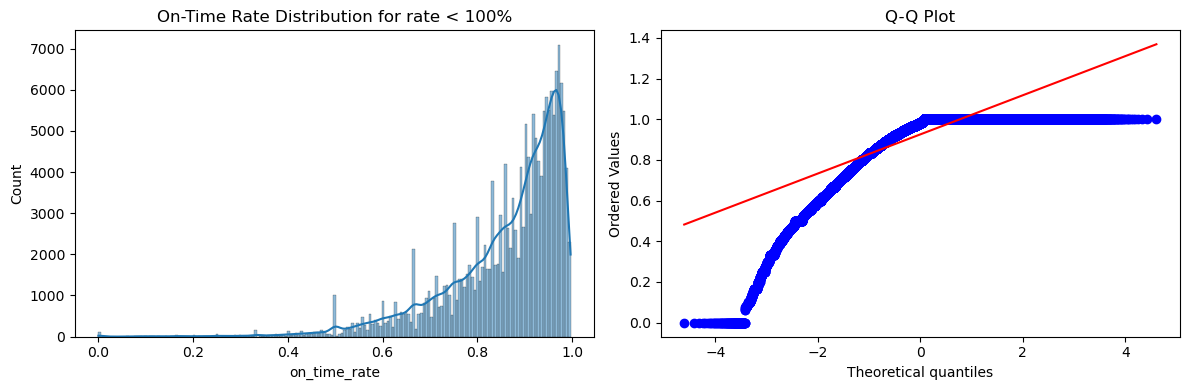

In [107]:
def main(target):

    logger = logging.getLogger(__name__)
    logger = setup_logging(logging.DEBUG)
    
    data_dir = "data/"
    df, raw_df = get_merged_data(data_dir, logger)    
        
    return df, raw_df, target

df, raw_df, target = main('LoanOutcome')


In [132]:
import importlib
importlib.reload(graph_structure_discovery)

logger = logging.getLogger(__name__)
logger = setup_logging(logging.DEBUG)
gsd.suggest_expert_list(df, 'LoanOutcome', logger)


DEBUG:__main__:Logger initialized — level: DEBUG, file: logs/bayesian_model_20260328_154336.log
DEBUG:__main__:============================================================
DEBUG:__main__:suggest_expert_list: starting structure discovery
DEBUG:__main__:============================================================
DEBUG:__main__:feature→target NMI (LoanOutcome):
  AmtReqCreditBureauMon        0.0173
  AmtGoodsPrice                0.0063
  AmtCredit                    0.0052
  ContractStatus               0.0048
  ExtSource3Risk               0.0045
  PriorLoanApproved            0.0042
  ExtSource1Risk               0.0038
  ExtSource2Risk               0.0037
  PrevRejected                 0.0026
  PaymentHistory               0.0024
  CreditProlonged              0.0022
  CreditUtilization            0.0018
  OccupationType               0.0008
  ActiveCredits                0.0006
  DebtLoad                     0.0006
  IncomeType                   0.0006
  DaysOverdue                 

DEBUG:__main__:  NMI(ContractStatus→LoanOutcome|ExtSource1Risk): 0.0048  (marginal=0.0048, ratio=1.01)
DEBUG:__main__:  NMI(ContractStatus→LoanOutcome|ExtSource2Risk): 0.0049  (marginal=0.0048, ratio=1.03)
DEBUG:__main__:  NMI(ContractStatus→LoanOutcome|PrevRejected): 0.0036  (marginal=0.0048, ratio=0.76)
DEBUG:__main__:  NMI(ContractStatus→LoanOutcome|PaymentHistory): 0.0018  (marginal=0.0048, ratio=0.38)
DEBUG:__main__:  NMI(ExtSource3Risk→LoanOutcome|PriorLoanApproved): 0.0046  (marginal=0.0045, ratio=1.01)
DEBUG:__main__:  NMI(ExtSource3Risk→LoanOutcome|ExtSource1Risk): 0.0041  (marginal=0.0045, ratio=0.91)
DEBUG:__main__:  NMI(ExtSource3Risk→LoanOutcome|ExtSource2Risk): 0.0042  (marginal=0.0045, ratio=0.92)
DEBUG:__main__:  NMI(ExtSource3Risk→LoanOutcome|PrevRejected): 0.0038  (marginal=0.0045, ratio=0.84)
DEBUG:__main__:  NMI(ExtSource3Risk→LoanOutcome|PaymentHistory): 0.0047  (marginal=0.0045, ratio=1.04)
DEBUG:__main__:  NMI(PriorLoanApproved→LoanOutcome|ExtSource1Risk): 0.0042

([('AmtReqCreditBureauMon', 'LoanOutcome'),
  ('AmtGoodsPrice', 'LoanOutcome'),
  ('AmtCredit', 'LoanOutcome'),
  ('ExtSource3Risk', 'LoanOutcome'),
  ('ExtSource1Risk', 'LoanOutcome'),
  ('ExtSource2Risk', 'LoanOutcome'),
  ('PrevRejected', 'LoanOutcome'),
  ('PaymentHistory', 'LoanOutcome'),
  ('CreditProlonged', 'LoanOutcome'),
  ('ContractStatus', 'PriorLoanApproved'),
  ('PriorLoanApproved', 'PaymentHistory'),
  ('AmtGoodsPrice', 'AmtCredit'),
  ('ActiveCredits', 'DebtLoad'),
  ('OccupationType', 'IncomeType'),
  ('ExtSource3Risk', 'ActiveCredits'),
  ('PaymentHistory', 'DPD'),
  ('AmtCredit', 'IncomeBracket'),
  ('ActiveCredits', 'MaxOverdue'),
  ('ExtSource1Risk', 'IncomeType'),
  ('PriorLoanApproved', 'PrevRejected'),
  ('CreditProlonged', 'MaxOverdue'),
  ('DebtLoad', 'IncomeBracket'),
  ('PriorLoanApproved', 'CreditUtilization'),
  ('OccupationType', 'IncomeBracket'),
  ('ExtSource3Risk', 'PrevRejected'),
  ('AmtReqCreditBureauMon', 'ActiveCredits'),
  ('ExtSource2Risk', 'Inc

In [125]:
print("got here")
# 1. What logger did setup_logging actually return?
print(repr(logger))
print("Name:", logger.name)
print("Handlers on this logger:", logger.handlers)

# 2. Check the root logger
root = logging.getLogger()
print("Root logger handlers:", root.handlers)

# 3. Dump every logger that has handlers
for name, l in logging.Logger.manager.loggerDict.items():
    if hasattr(l, 'handlers') and l.handlers:
        print(f"Logger '{name}':")
        for h in l.handlers:
            if isinstance(h, logging.FileHandler):
                print(f"  File → {h.baseFilename}")
            elif isinstance(h, logging.StreamHandler):
                print(f"  Stream → {h.stream.name}")

got here
<Logger __main__ (INFO)>
Name: __main__
Handlers on this logger: []
Root logger handlers: [<StreamHandler stderr (NOTSET)>]
Logger 'tornado':
  Stream → <stderr>
Logger 'IPKernelApp':
  Stream → <stderr>
Logger 'torch':
  Stream → stderr
Logger 'strobelight_function_profiler':
  Stream → stderr
Logger 'strobelight_compile_time_profiler':
  Stream → stderr
Logger 'torch.distributed':
  Stream → stderr
Logger 'c10d-NullHandler-default':
Logger 'torch.distributed.distributed_c10d':
  Stream → stderr
Logger 'torch.autograd':
  Stream → stderr
Logger 'torch.nn.parallel.distributed':
  Stream → stderr
Logger 'torch.__trace':


AttributeError: 'NoneType' object has no attribute 'name'

In [52]:
raw_df[0:5]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,max_days_overdue,max_overdue_amt,total_debt,total_prolonged,active_credits,DaysOverdue,MaxOverdue,DebtLoad,CreditProlonged,ActiveCredits
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,5043.645,245781.0,0.0,2.0,None,Medium,High,Never,Few
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.000,0.0,0.0,1.0,None,None,None,Never,One
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.000,0.0,0.0,0.0,None,None,None,Never,None
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.000,0.0,0.0,0.0,None,None,None,Never,None


In [57]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
raw_df.info(verbose=True, show_counts=True)
#raw_df.columns

<class 'pandas.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Data columns (total 155 columns):
 #    Column                        Non-Null Count   Dtype   
---   ------                        --------------   -----   
 0    SK_ID_CURR                    356255 non-null  int64   
 1    TARGET                        307511 non-null  float64 
 2    NAME_CONTRACT_TYPE            356255 non-null  str     
 3    CODE_GENDER                   356255 non-null  str     
 4    FLAG_OWN_CAR                  356255 non-null  str     
 5    FLAG_OWN_REALTY               356255 non-null  str     
 6    CNT_CHILDREN                  356255 non-null  int64   
 7    AMT_INCOME_TOTAL              356255 non-null  float64 
 8    AMT_CREDIT                    356255 non-null  float64 
 9    AMT_ANNUITY                   356219 non-null  float64 
 10   AMT_GOODS_PRICE               355977 non-null  float64 
 11   NAME_TYPE_SUITE               354052 non-null  str     
 12   NAME_INCOME_TYPE         

In [ ]:
candidates = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL',
              'AMT_GOODS_PRICE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
              'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'on_time_rate',
              'avg_utilization', 'max_days_overdue', 'prior_refused', 'active_credits',
              'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS', 'CODE_GENDER',
              'REGION_RATING_CLIENT']
              

CONTINUOUS FEATURES

────────────────────────────────────────


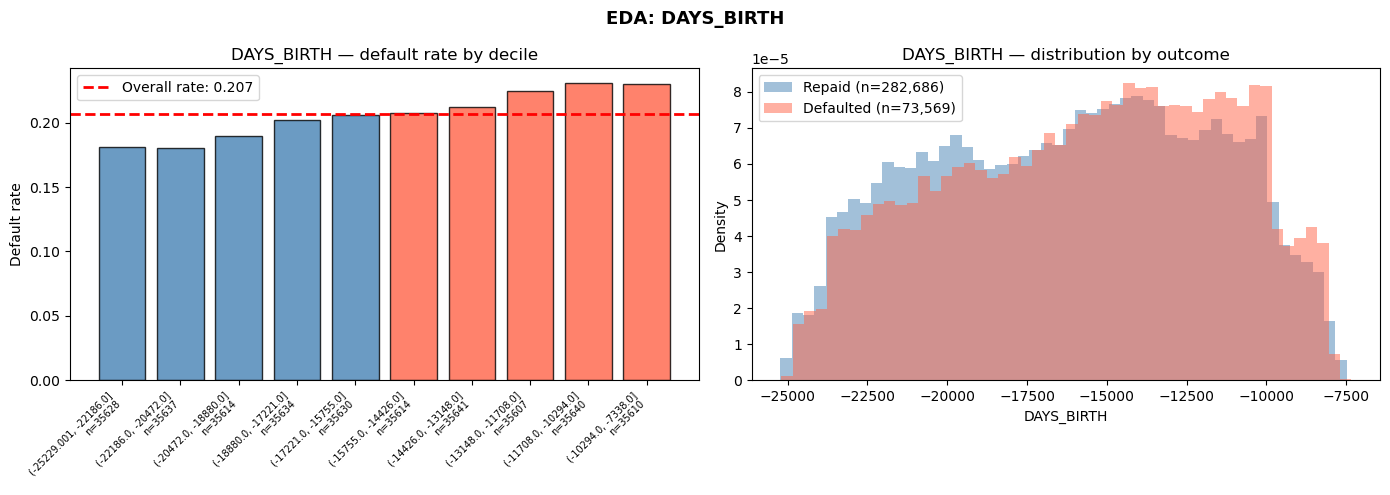


DAYS_BIRTH — default rate by decile:
                   decile  midpoint  default_rate    count
0  (-25229.001, -22186.0]  -23204.0      0.181374  35628.0
1    (-22186.0, -20472.0]  -21314.0      0.180599  35637.0
2    (-20472.0, -18880.0]  -19675.0      0.189616  35614.0
3    (-18880.0, -17221.0]  -18030.0      0.201914  35634.0
4    (-17221.0, -15755.0]  -16466.0      0.206175  35630.0
5    (-15755.0, -14426.0]  -15077.0      0.207334  35614.0
6    (-14426.0, -13148.0]  -13794.0      0.212284  35641.0
7    (-13148.0, -11708.0]  -12425.0      0.224843  35607.0
8    (-11708.0, -10294.0]  -11015.0      0.230612  35640.0
9     (-10294.0, -7338.0]   -9417.0      0.230329  35610.0
  Max spread: 0.231 - 0.181 = 0.050pp
Max spread: 0.05001285644086667 Default signal strength: Moderate — worth rebinning or adding as supporting node



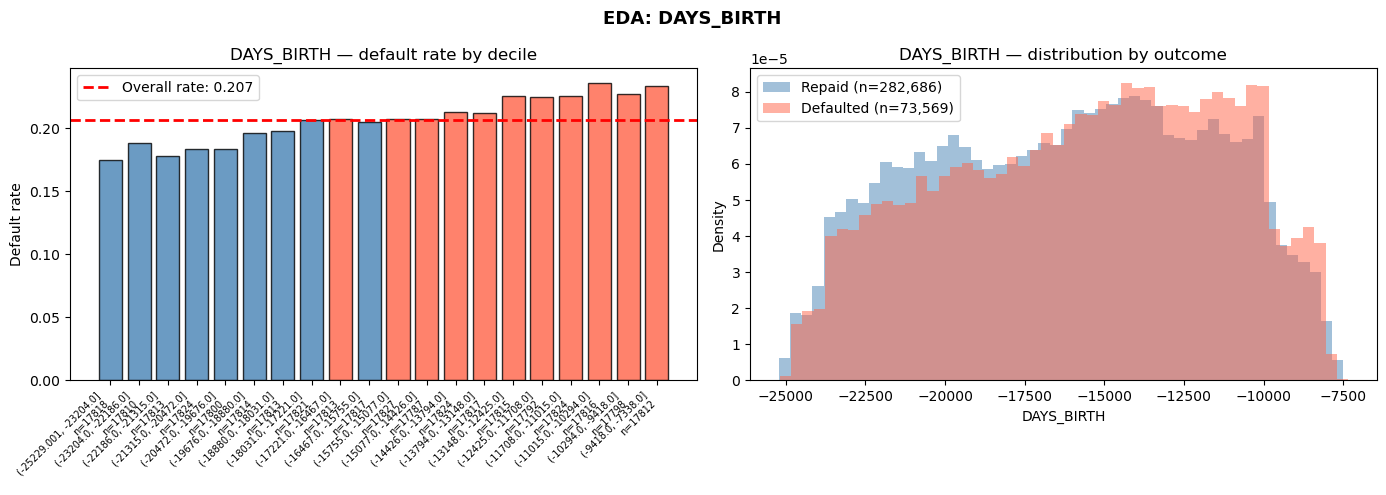


DAYS_BIRTH — default rate by decile:
                    decile  midpoint  default_rate    count
0   (-25229.001, -23204.0]  -23756.0      0.174430  17818.0
1     (-23204.0, -22186.0]  -22691.0      0.188321  17810.0
2     (-22186.0, -21315.0]  -21751.0      0.177792  17813.0
3     (-21315.0, -20472.0]  -20876.0      0.183404  17824.0
4     (-20472.0, -19676.0]  -20052.0      0.183315  17800.0
5     (-19676.0, -18880.0]  -19292.0      0.195913  17814.0
6     (-18880.0, -18031.0]  -18449.0      0.197665  17813.0
7     (-18031.0, -17221.0]  -17621.0      0.206161  17821.0
8     (-17221.0, -16467.0]  -16832.0      0.207545  17813.0
9     (-16467.0, -15755.0]  -16091.0      0.204804  17817.0
10    (-15755.0, -15077.0]  -15415.0      0.207045  17827.0
11    (-15077.0, -14426.0]  -14752.0      0.207624  17787.0
12    (-14426.0, -13794.0]  -14116.0      0.212859  17824.0
13    (-13794.0, -13148.0]  -13477.0      0.211708  17817.0
14    (-13148.0, -12425.0]  -12789.0      0.225091  17815.0
15

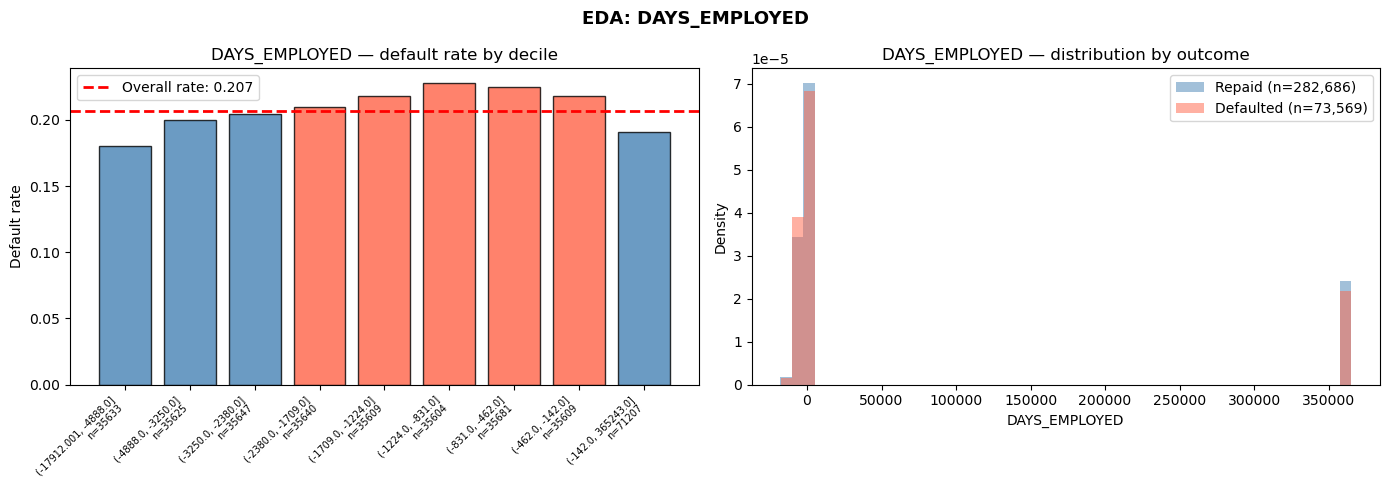


DAYS_EMPLOYED — default rate by decile:
                  decile  midpoint  default_rate    count
0  (-17912.001, -4888.0]   -6739.0      0.180170  35633.0
1     (-4888.0, -3250.0]   -3892.0      0.200168  35625.0
2     (-3250.0, -2380.0]   -2781.0      0.204225  35647.0
3     (-2380.0, -1709.0]   -2011.0      0.209820  35640.0
4     (-1709.0, -1224.0]   -1459.0      0.218456  35609.0
5      (-1224.0, -831.0]   -1022.0      0.227643  35604.0
6       (-831.0, -462.0]    -647.0      0.225274  35681.0
7       (-462.0, -142.0]    -290.0      0.217782  35609.0
8     (-142.0, 365243.0]  365243.0      0.190754  71207.0
  Max spread: 0.228 - 0.180 = 0.047pp
Max spread: 0.04747289439234656 Default signal strength: Weak     — marginal value, only add if CPT cost is low



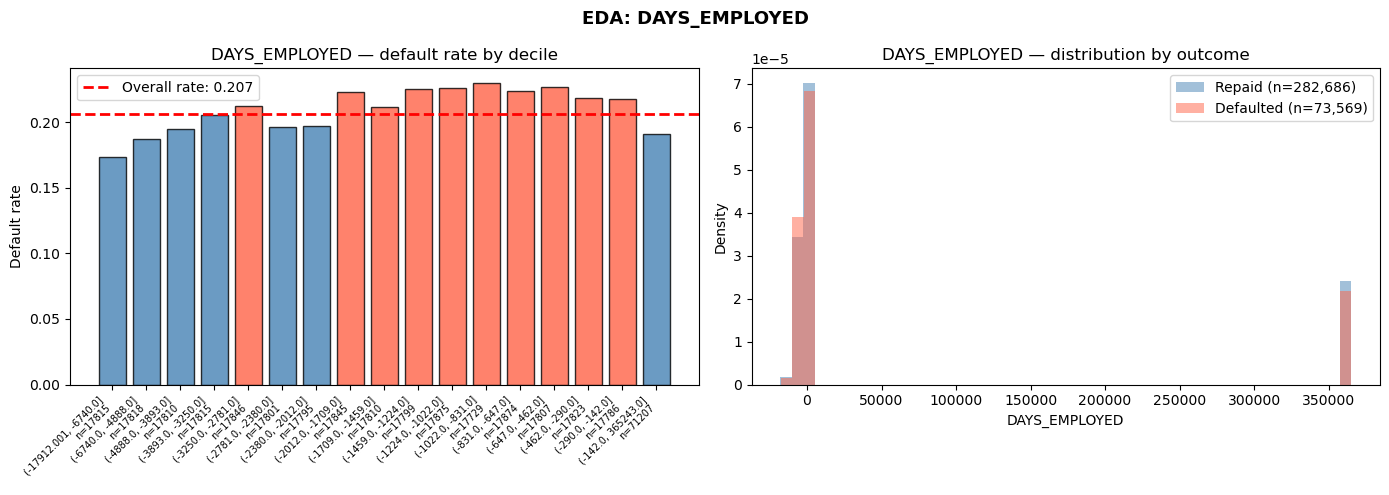


DAYS_EMPLOYED — default rate by decile:
                   decile  midpoint  default_rate    count
0   (-17912.001, -6740.0]   -8556.0      0.173056  17815.0
1      (-6740.0, -4888.0]   -5514.5      0.187283  17818.0
2      (-4888.0, -3893.0]   -4343.0      0.194554  17810.0
3      (-3893.0, -3250.0]   -3543.0      0.205782  17815.0
4      (-3250.0, -2781.0]   -3006.0      0.212316  17846.0
5      (-2781.0, -2380.0]   -2574.0      0.196113  17801.0
6      (-2380.0, -2012.0]   -2195.0      0.197022  17795.0
7      (-2012.0, -1709.0]   -1849.0      0.222583  17845.0
8      (-1709.0, -1459.0]   -1583.0      0.211398  17810.0
9      (-1459.0, -1224.0]   -1335.0      0.225518  17799.0
10     (-1224.0, -1022.0]   -1120.0      0.225790  17875.0
11      (-1022.0, -831.0]    -924.0      0.229511  17729.0
12       (-831.0, -647.0]    -739.0      0.223789  17874.0
13       (-647.0, -462.0]    -553.0      0.226765  17807.0
14       (-462.0, -290.0]    -380.0      0.218257  17823.0
15       (-290.

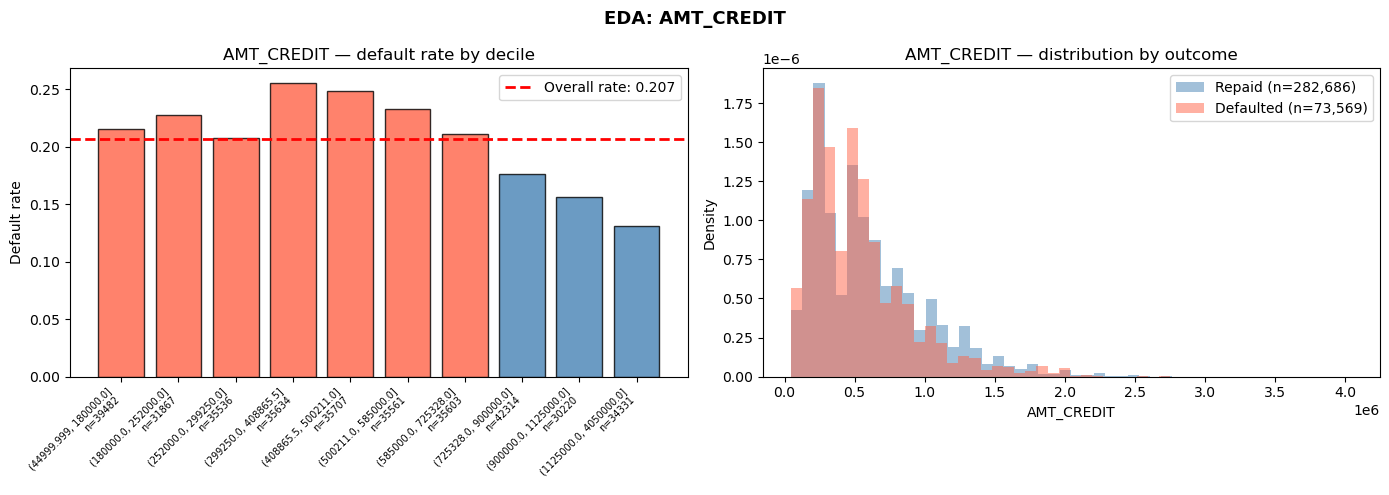


AMT_CREDIT — default rate by decile:
                   decile   midpoint  default_rate    count
0   (44999.999, 180000.0]   140215.5      0.215541  39482.0
1    (180000.0, 252000.0]   225000.0      0.227885  31867.0
2    (252000.0, 299250.0]   270000.0      0.207170  35536.0
3    (299250.0, 408865.5]   343800.0      0.255290  35634.0
4    (408865.5, 500211.0]   450000.0      0.248523  35707.0
5    (500211.0, 585000.0]   540000.0      0.232699  35561.0
6    (585000.0, 725328.0]   675000.0      0.211078  35603.0
7    (725328.0, 900000.0]   808650.0      0.176206  42314.0
8   (900000.0, 1125000.0]  1027327.5      0.156122  30220.0
9  (1125000.0, 4050000.0]  1350000.0      0.131077  34331.0
  Max spread: 0.255 - 0.131 = 0.124pp
Max spread: 0.12421302237469153 Default signal strength: Strong   — worth adding as direct LoanOutcome parent



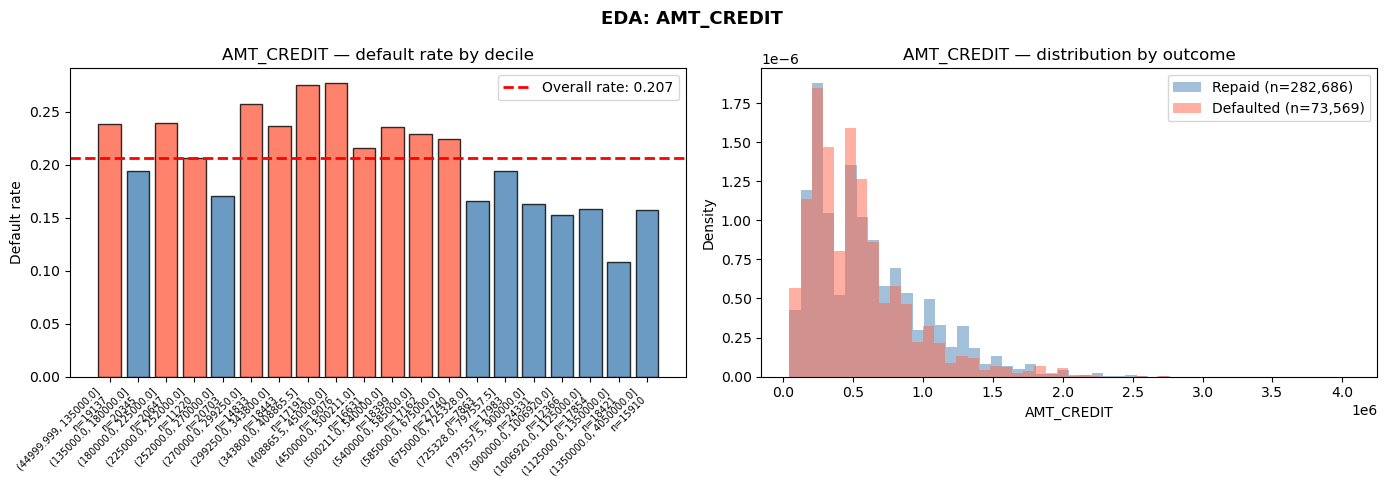


AMT_CREDIT — default rate by decile:
                    decile   midpoint  default_rate    count
0    (44999.999, 135000.0]   107820.0      0.238230  19137.0
1     (135000.0, 180000.0]   170640.0      0.194200  20345.0
2     (180000.0, 225000.0]   222768.0      0.239308  20647.0
3     (225000.0, 252000.0]   241618.5      0.206863  11220.0
4     (252000.0, 270000.0]   269550.0      0.170941  20703.0
5     (270000.0, 299250.0]   284400.0      0.257736  14833.0
6     (299250.0, 343800.0]   317421.0      0.236892  18443.0
7     (343800.0, 408865.5]   376078.5      0.275028  17191.0
8     (408865.5, 450000.0]   450000.0      0.277207  19076.0
9     (450000.0, 500211.0]   481176.0      0.215621  16631.0
10    (500211.0, 540000.0]   521280.0      0.235774  18399.0
11    (540000.0, 585000.0]   553581.0      0.229402  17162.0
12    (585000.0, 675000.0]   646920.0      0.224045  27740.0
13    (675000.0, 725328.0]   697500.0      0.165331   7863.0
14    (725328.0, 797557.5]   760225.5      0.19

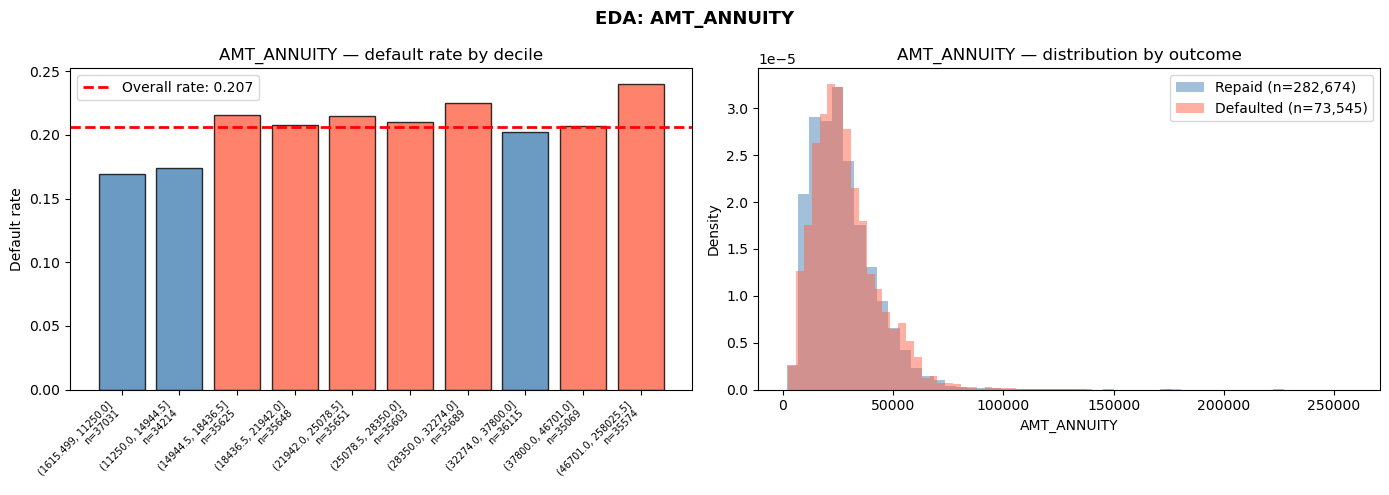


AMT_ANNUITY — default rate by decile:
                decile  midpoint  default_rate    count
0  (1615.499, 11250.0]    9000.0      0.169318  37031.0
1   (11250.0, 14944.5]   13500.0      0.173642  34214.0
2   (14944.5, 18436.5]   16731.0      0.215242  35625.0
3   (18436.5, 21942.0]   20259.0      0.207613  35648.0
4   (21942.0, 25078.5]   23539.5      0.214580  35651.0
5   (25078.5, 28350.0]   26509.5      0.210432  35603.0
6   (28350.0, 32274.0]   30307.5      0.225308  35689.0
7   (32274.0, 37800.0]   35028.0      0.201938  36115.0
8   (37800.0, 46701.0]   41728.5      0.206564  35069.0
9  (46701.0, 258025.5]   53968.5      0.240204  35574.0
  Max spread: 0.240 - 0.169 = 0.071pp
Max spread: 0.07088592065569937 Default signal strength: Moderate — worth rebinning or adding as supporting node



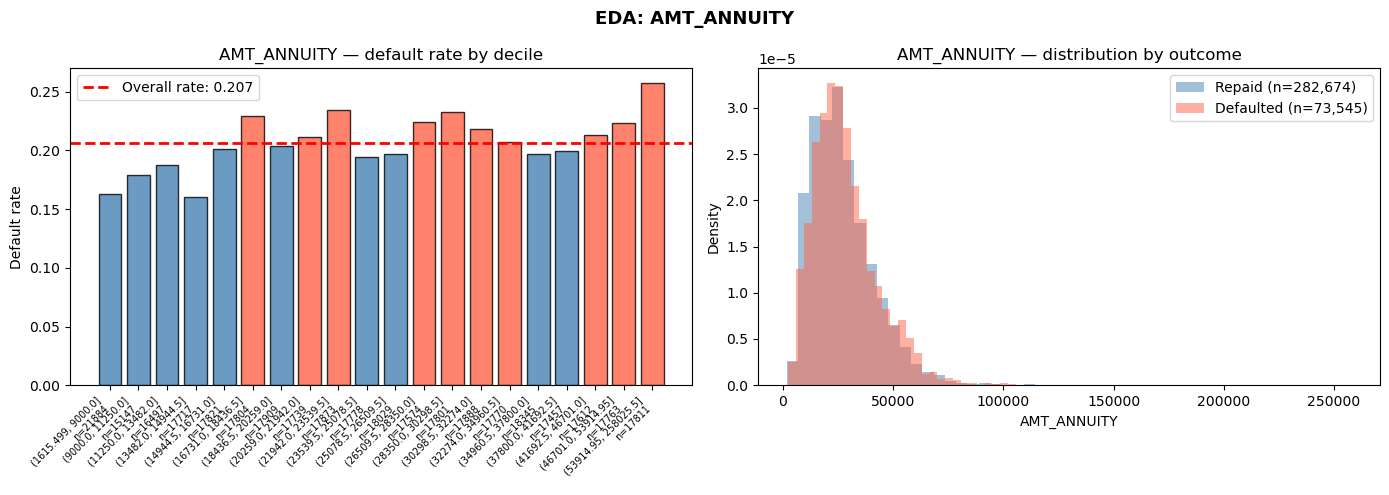


AMT_ANNUITY — default rate by decile:
                  decile  midpoint  default_rate    count
0     (1615.499, 9000.0]    7875.0      0.162630  21884.0
1      (9000.0, 11250.0]   10233.0      0.178979  15147.0
2     (11250.0, 13482.0]   12375.0      0.187670  16497.0
3     (13482.0, 14944.5]   13932.0      0.160580  17717.0
4     (14944.5, 16731.0]   16011.0      0.201223  17821.0
5     (16731.0, 18436.5]   17541.0      0.229274  17804.0
6     (18436.5, 20259.0]   19417.5      0.203752  17909.0
7     (20259.0, 21942.0]   21276.0      0.211511  17739.0
8     (21942.0, 23539.5]   22599.0      0.234712  17873.0
9     (23539.5, 25078.5]   24309.0      0.194341  17778.0
10    (25078.5, 26509.5]   25965.0      0.196850  18029.0
11    (26509.5, 28350.0]   27292.5      0.224366  17574.0
12    (28350.0, 30298.5]   29367.0      0.232796  17801.0
13    (30298.5, 32274.0]   31279.5      0.217856  17888.0
14    (32274.0, 34960.5]   33403.5      0.206922  17770.0
15    (34960.5, 37800.0]   36441.

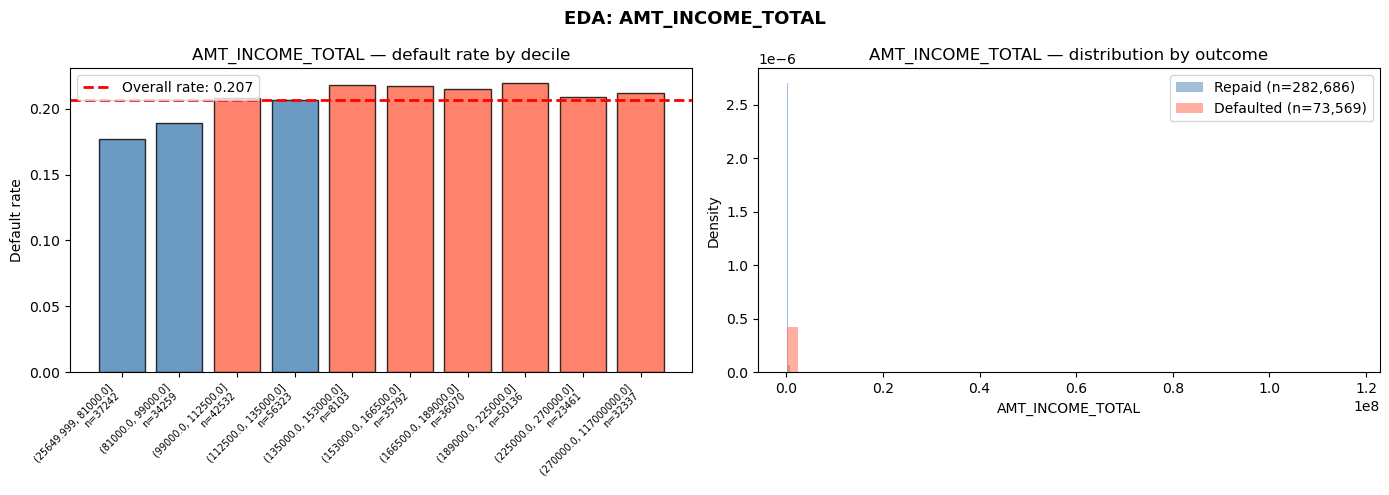


AMT_INCOME_TOTAL — default rate by decile:
                    decile  midpoint  default_rate    count
0     (25649.999, 81000.0]   67500.0      0.176843  37242.0
1       (81000.0, 99000.0]   90000.0      0.188826  34259.0
2      (99000.0, 112500.0]  112500.0      0.207914  42532.0
3     (112500.0, 135000.0]  135000.0      0.206328  56323.0
4     (135000.0, 153000.0]  144000.0      0.218191   8103.0
5     (153000.0, 166500.0]  157500.0      0.217143  35792.0
6     (166500.0, 189000.0]  180000.0      0.214721  36070.0
7     (189000.0, 225000.0]  216000.0      0.219663  50136.0
8     (225000.0, 270000.0]  270000.0      0.209241  23461.0
9  (270000.0, 117000000.0]  360000.0      0.211615  32337.0
  Max spread: 0.220 - 0.177 = 0.043pp
Max spread: 0.04281916904402497 Default signal strength: Weak     — marginal value, only add if CPT cost is low



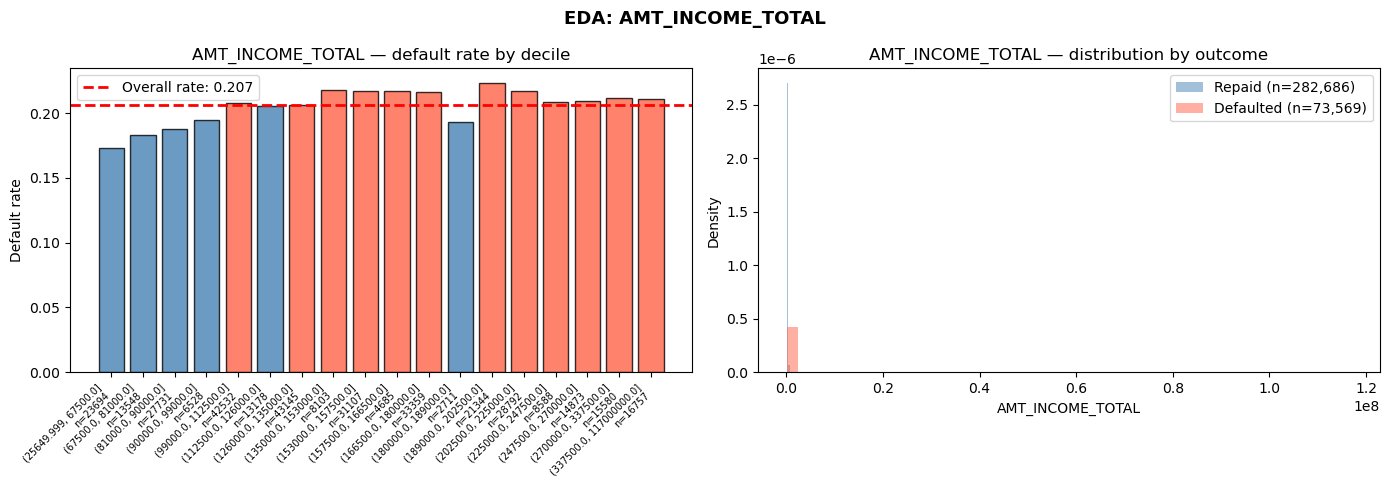


AMT_INCOME_TOTAL — default rate by decile:
                     decile  midpoint  default_rate    count
0      (25649.999, 67500.0]   67500.0      0.173251  23694.0
1        (67500.0, 81000.0]   79650.0      0.183127  13548.0
2        (81000.0, 90000.0]   90000.0      0.187480  27731.0
3        (90000.0, 99000.0]   99000.0      0.194547   6528.0
4       (99000.0, 112500.0]  112500.0      0.207914  42532.0
5      (112500.0, 126000.0]  121500.0      0.205418  13178.0
6      (126000.0, 135000.0]  135000.0      0.206606  43145.0
7      (135000.0, 153000.0]  144000.0      0.218191   8103.0
8      (153000.0, 157500.0]  157500.0      0.217154  31107.0
9      (157500.0, 166500.0]  166500.0      0.217076   4685.0
10     (166500.0, 180000.0]  180000.0      0.216493  33359.0
11     (180000.0, 189000.0]  189000.0      0.192918   2711.0
12     (189000.0, 202500.0]  202500.0      0.223482  21344.0
13     (202500.0, 225000.0]  225000.0      0.216831  28792.0
14     (225000.0, 247500.0]  247500.0    

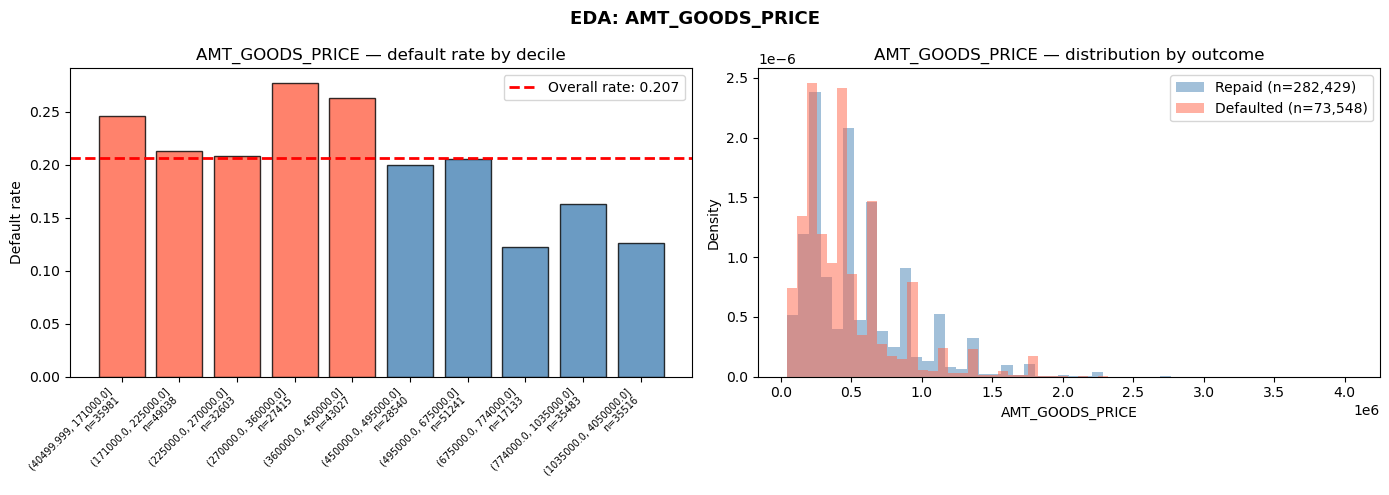


AMT_GOODS_PRICE — default rate by decile:
                   decile   midpoint  default_rate    count
0   (40499.999, 171000.0]   135000.0      0.245435  35981.0
1    (171000.0, 225000.0]   225000.0      0.213284  49038.0
2    (225000.0, 270000.0]   252000.0      0.207864  32603.0
3    (270000.0, 360000.0]   319500.0      0.277038  27415.0
4    (360000.0, 450000.0]   450000.0      0.263230  43027.0
5    (450000.0, 495000.0]   463500.0      0.199369  28540.0
6    (495000.0, 675000.0]   675000.0      0.205324  51241.0
7    (675000.0, 774000.0]   697500.0      0.122220  17133.0
8   (774000.0, 1035000.0]   900000.0      0.162500  35483.0
9  (1035000.0, 4050000.0]  1305000.0      0.126394  35516.0
  Max spread: 0.277 - 0.122 = 0.155pp
Max spread: 0.15481784115963343 Default signal strength: Strong   — worth adding as direct LoanOutcome parent



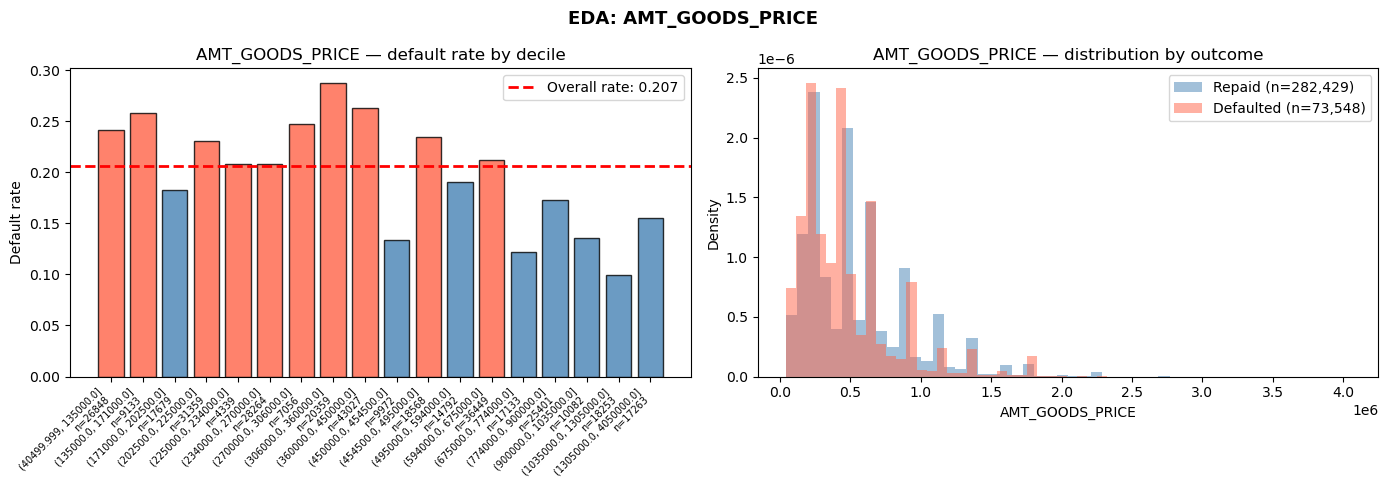


AMT_GOODS_PRICE — default rate by decile:
                    decile   midpoint  default_rate    count
0    (40499.999, 135000.0]   112500.0      0.241098  26848.0
1     (135000.0, 171000.0]   157500.0      0.258185   9133.0
2     (171000.0, 202500.0]   180000.0      0.182420  17679.0
3     (202500.0, 225000.0]   225000.0      0.230683  31359.0
4     (225000.0, 234000.0]   229500.0      0.207652   4339.0
5     (234000.0, 270000.0]   256500.0      0.207897  28264.0
6     (270000.0, 306000.0]   292500.0      0.247449   7056.0
7     (306000.0, 360000.0]   337500.0      0.287293  20359.0
8     (360000.0, 450000.0]   450000.0      0.263230  43027.0
9     (450000.0, 454500.0]   454500.0      0.133875   9972.0
10    (454500.0, 495000.0]   472500.0      0.234543  18568.0
11    (495000.0, 594000.0]   540000.0      0.190035  14792.0
12    (594000.0, 675000.0]   675000.0      0.211528  36449.0
13    (675000.0, 774000.0]   697500.0      0.122220  17133.0
14    (774000.0, 900000.0]   900000.0     

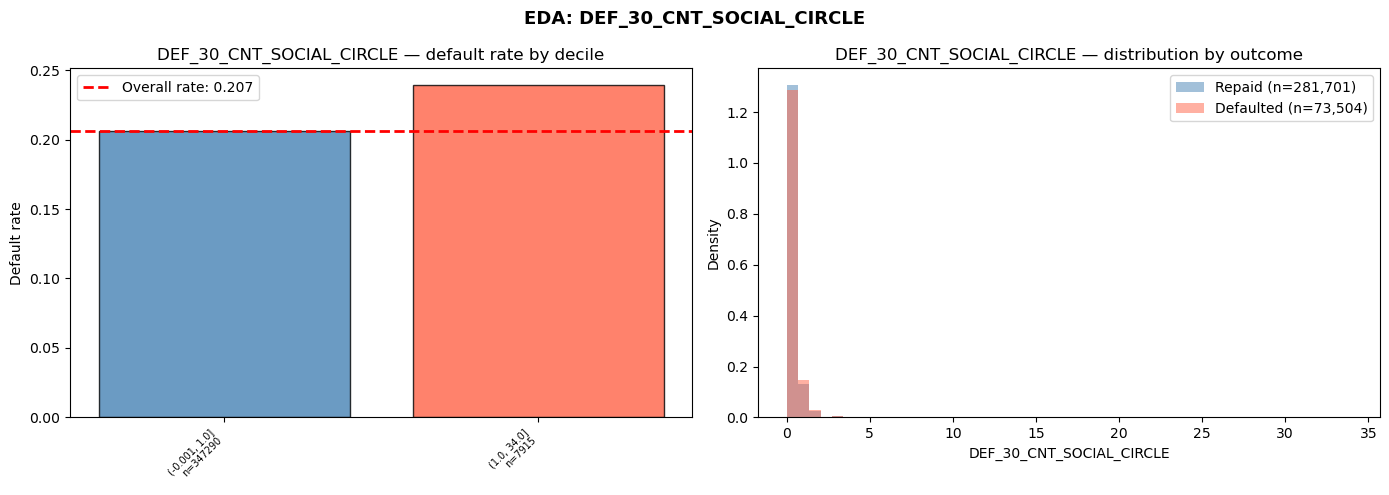


DEF_30_CNT_SOCIAL_CIRCLE — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.206197  347290.0
1    (1.0, 34.0]       2.0      0.239292    7915.0
  Max spread: 0.239 - 0.206 = 0.033pp
Max spread: 0.03309593219456625 Default signal strength: Weak     — marginal value, only add if CPT cost is low



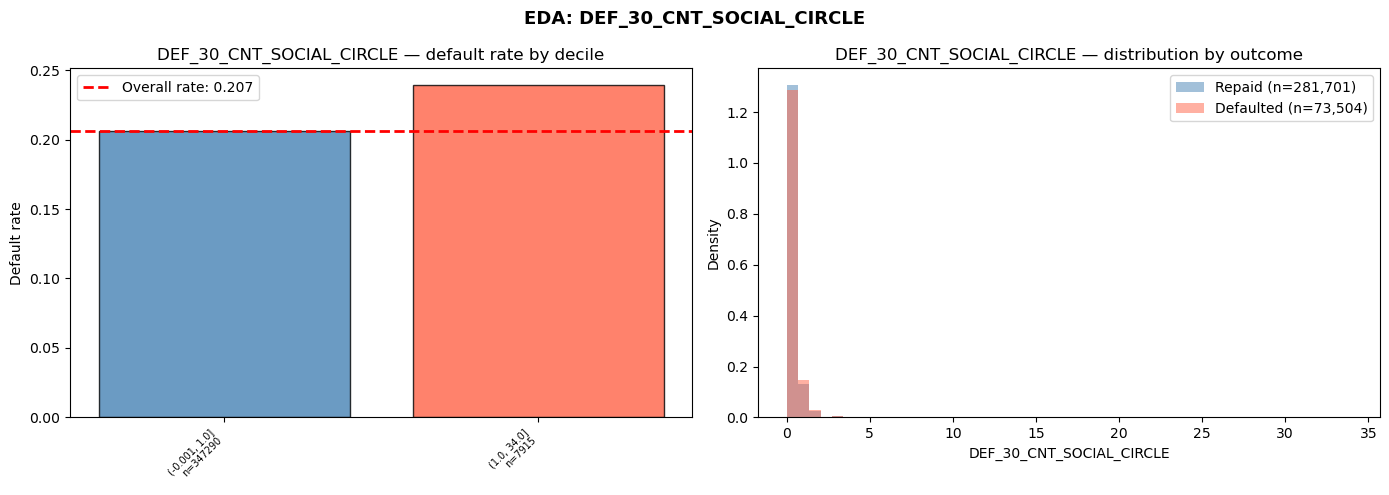


DEF_30_CNT_SOCIAL_CIRCLE — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.206197  347290.0
1    (1.0, 34.0]       2.0      0.239292    7915.0
  Max spread: 0.239 - 0.206 = 0.033pp
Max spread: 0.03309593219456625 Default signal strength: Weak     — marginal value, only add if CPT cost is low


────────────────────────────────────────


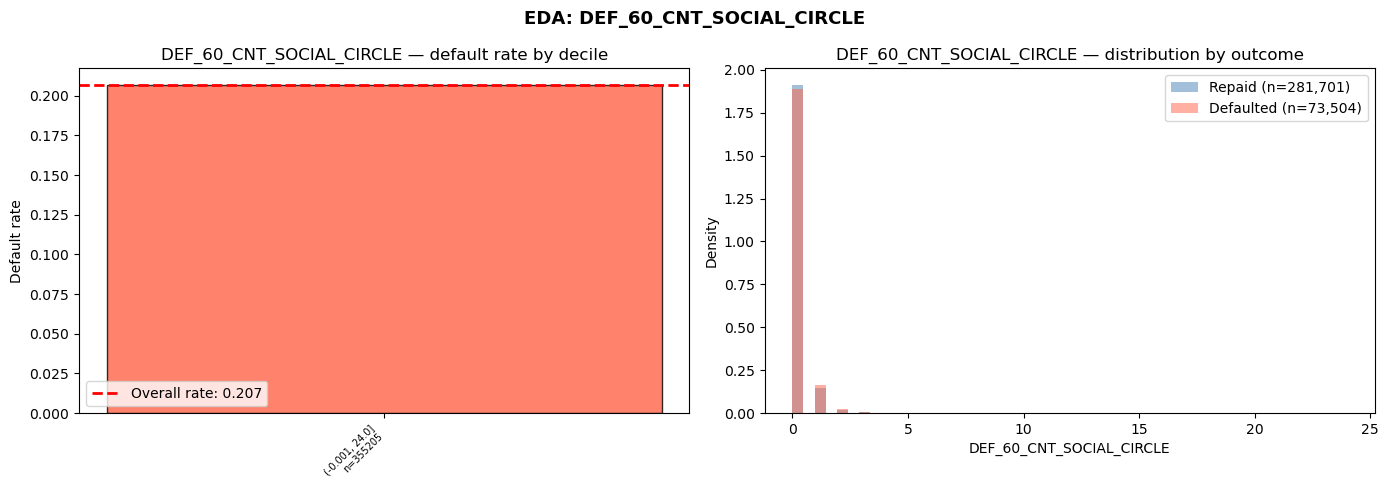


DEF_60_CNT_SOCIAL_CIRCLE — default rate by decile:
           decile  midpoint  default_rate     count
0  (-0.001, 24.0]       0.0      0.206934  355205.0
  Max spread: 0.207 - 0.207 = 0.000pp
Max spread: 0.0 Default signal strength: Drop     — confirmed no signal



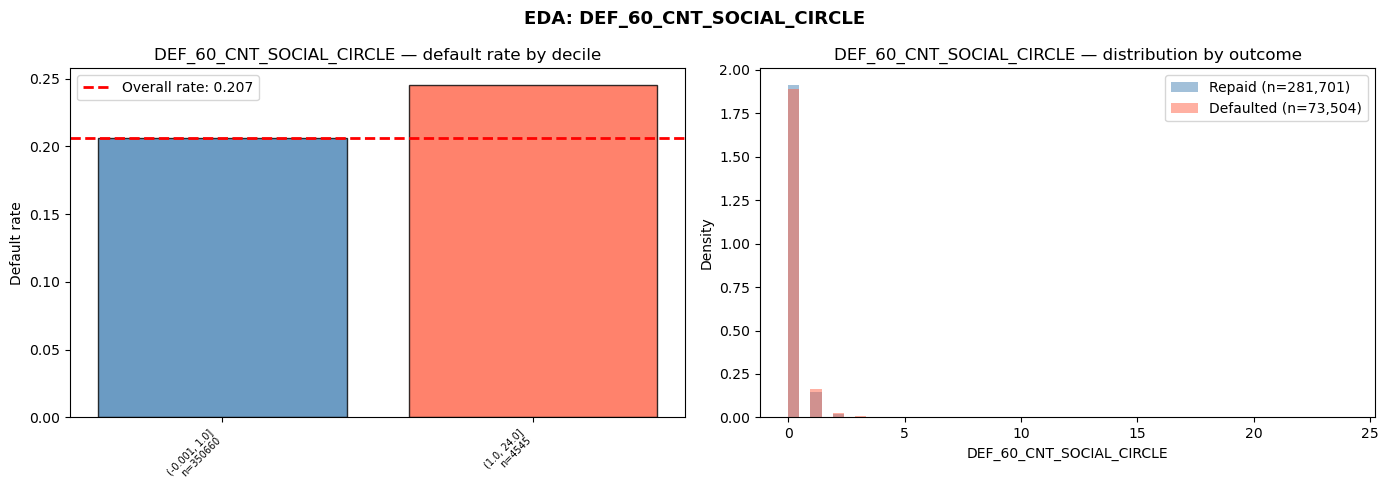


DEF_60_CNT_SOCIAL_CIRCLE — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.206436  350660.0
1    (1.0, 24.0]       2.0      0.245325    4545.0
  Max spread: 0.245 - 0.206 = 0.039pp
Max spread: 0.03888809830050477 Default signal strength: Weak     — marginal value, only add if CPT cost is low


────────────────────────────────────────


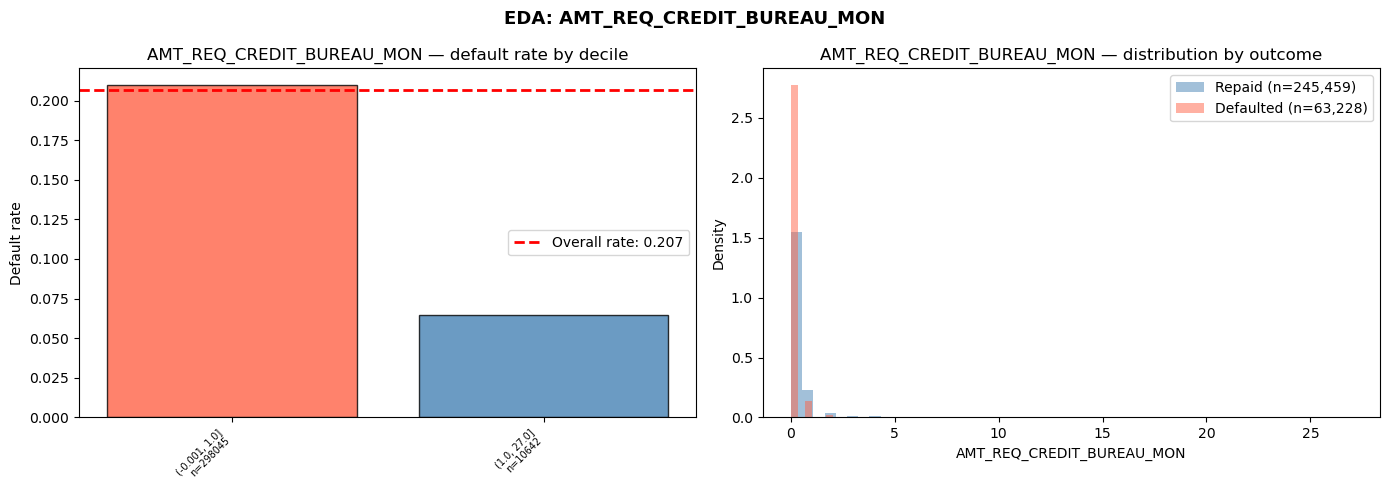


AMT_REQ_CREDIT_BUREAU_MON — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.209834  298045.0
1    (1.0, 27.0]       2.0      0.064650   10642.0
  Max spread: 0.210 - 0.065 = 0.145pp
Max spread: 0.1451845834835808 Default signal strength: Strong   — worth adding as direct LoanOutcome parent



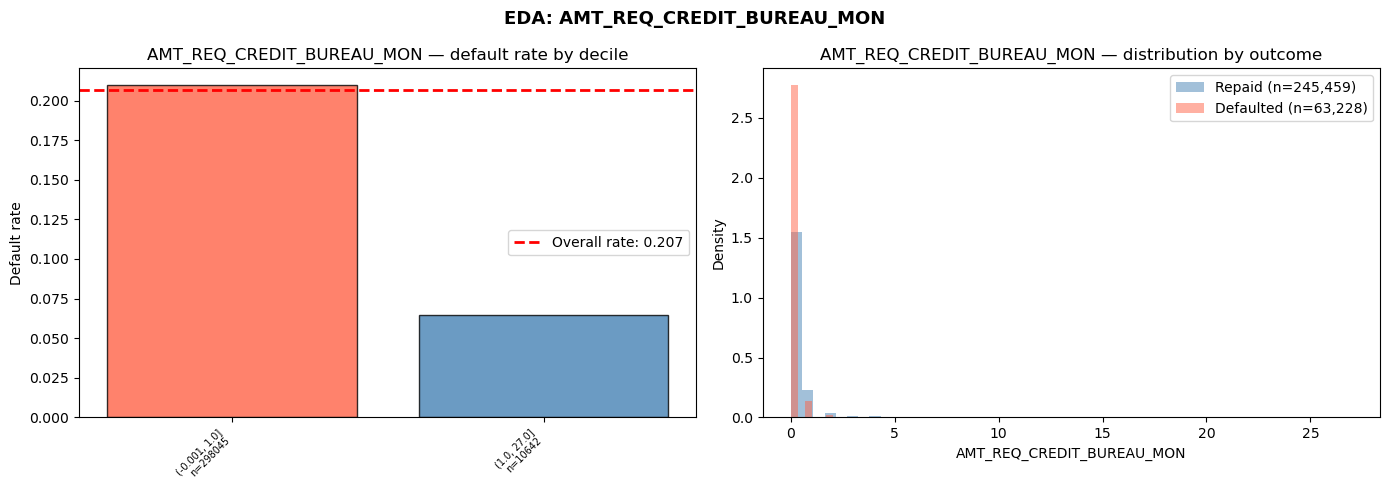


AMT_REQ_CREDIT_BUREAU_MON — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.209834  298045.0
1    (1.0, 27.0]       2.0      0.064650   10642.0
  Max spread: 0.210 - 0.065 = 0.145pp
Max spread: 0.1451845834835808 Default signal strength: Strong   — worth adding as direct LoanOutcome parent


────────────────────────────────────────


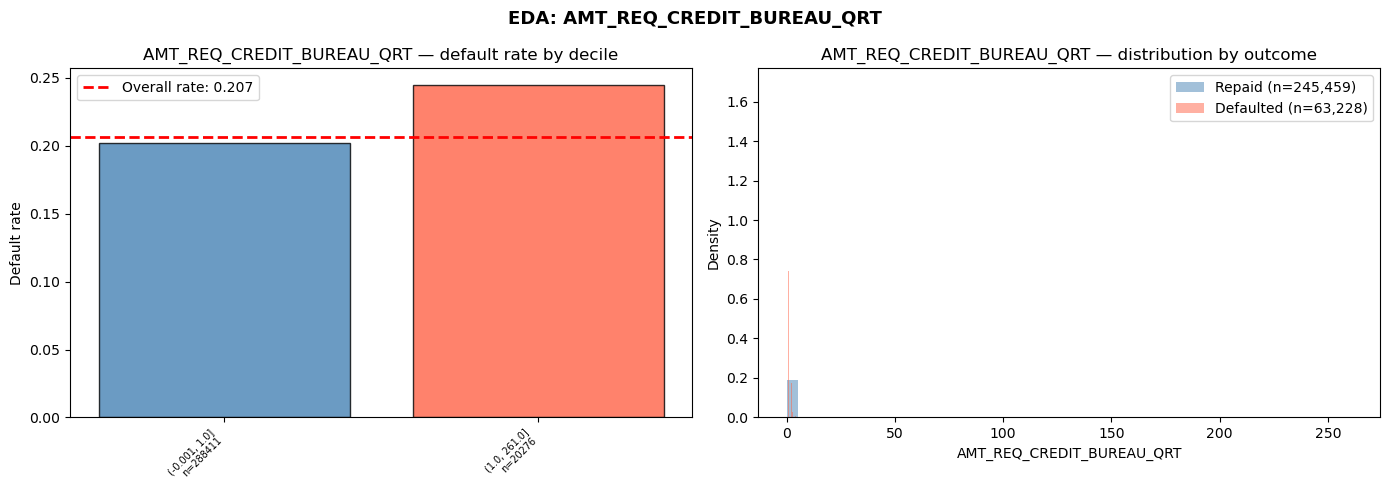


AMT_REQ_CREDIT_BUREAU_QRT — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.202017  288411.0
1   (1.0, 261.0]       2.0      0.244821   20276.0
  Max spread: 0.245 - 0.202 = 0.043pp
Max spread: 0.042804203708931426 Default signal strength: Weak     — marginal value, only add if CPT cost is low



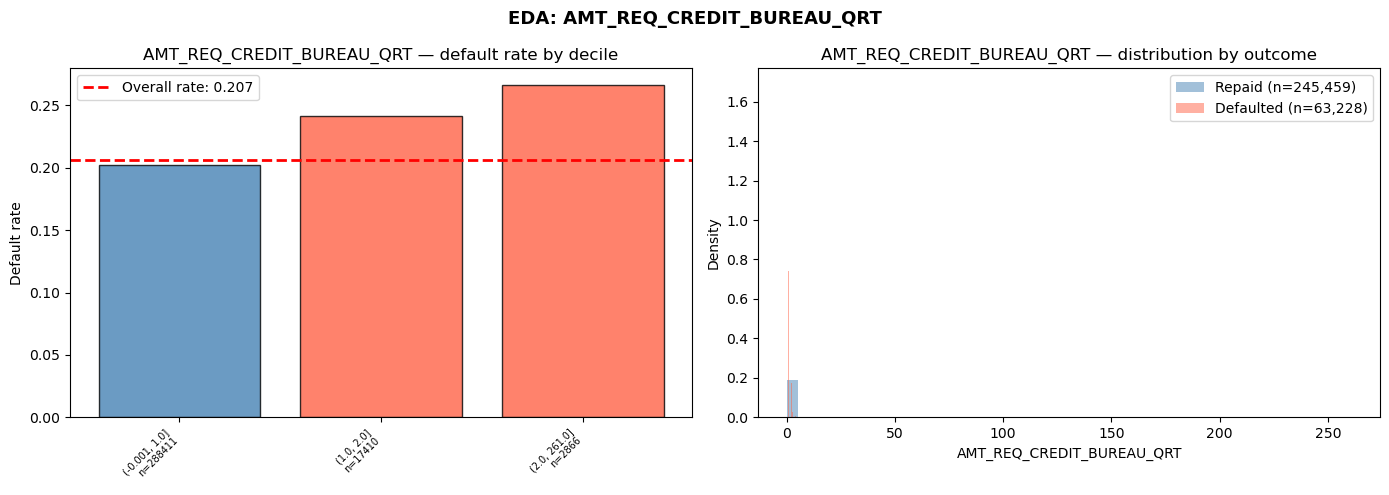


AMT_REQ_CREDIT_BUREAU_QRT — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.202017  288411.0
1     (1.0, 2.0]       2.0      0.241298   17410.0
2   (2.0, 261.0]       3.0      0.266225    2866.0
  Max spread: 0.266 - 0.202 = 0.064pp
Max spread: 0.0642074433287653 Default signal strength: Moderate — worth rebinning or adding as supporting node


────────────────────────────────────────


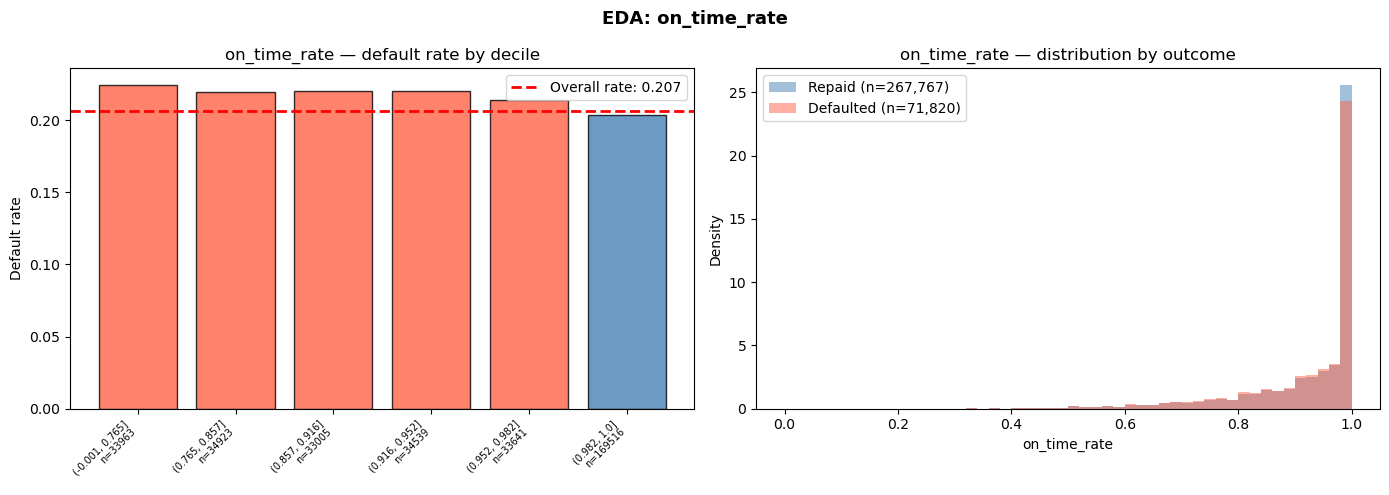


on_time_rate — default rate by decile:
            decile  midpoint  default_rate     count
0  (-0.001, 0.765]  0.678571      0.224627   33963.0
1   (0.765, 0.857]  0.821990      0.219282   34923.0
2   (0.857, 0.916]  0.891304      0.220482   33005.0
3   (0.916, 0.952]  0.935484      0.220215   34539.0
4   (0.952, 0.982]  0.967742      0.213727   33641.0
5     (0.982, 1.0]  1.000000      0.203285  169516.0
  Max spread: 0.225 - 0.203 = 0.021pp
Max spread: 0.02134215405551068 Default signal strength: Skip     — noise level, not worth adding



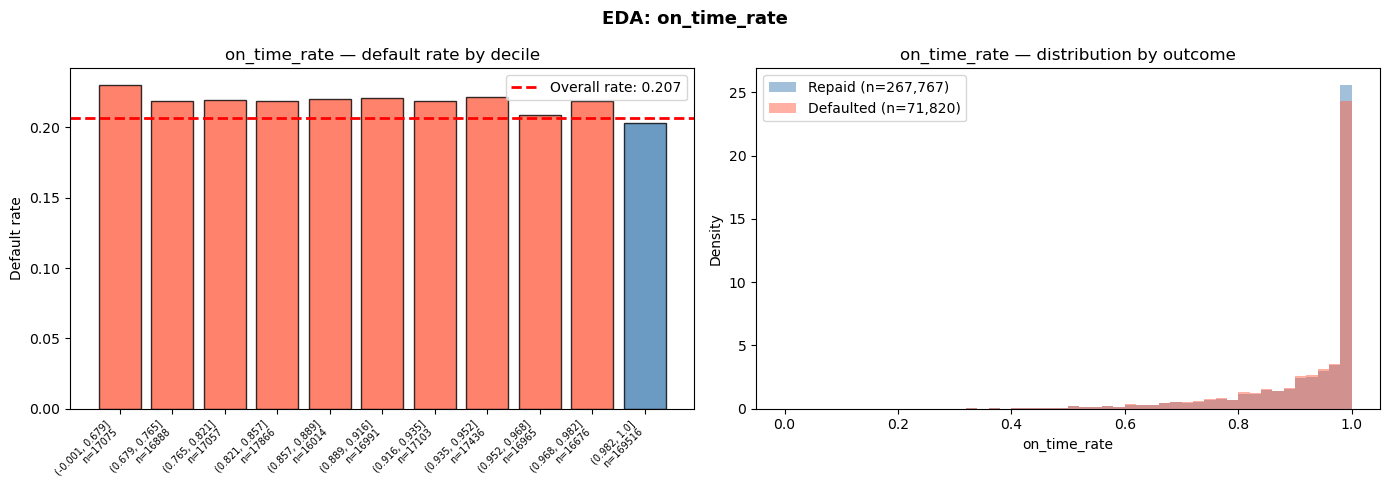


on_time_rate — default rate by decile:
             decile  midpoint  default_rate     count
0   (-0.001, 0.679]  0.600000      0.230454   17075.0
1    (0.679, 0.765]  0.727273      0.218735   16888.0
2    (0.765, 0.821]  0.797980      0.219792   17057.0
3    (0.821, 0.857]  0.842105      0.218795   17866.0
4    (0.857, 0.889]  0.875000      0.219995   16014.0
5    (0.889, 0.916]  0.903226      0.220940   16991.0
6    (0.916, 0.935]  0.923077      0.218617   17103.0
7    (0.935, 0.952]  0.944444      0.221783   17436.0
8    (0.952, 0.968]  0.960396      0.208724   16965.0
9    (0.968, 0.982]  0.975000      0.218817   16676.0
10     (0.982, 1.0]  1.000000      0.203285  169516.0
  Max spread: 0.230 - 0.203 = 0.027pp
Max spread: 0.027169234244273505 Default signal strength: Skip     — noise level, not worth adding


────────────────────────────────────────


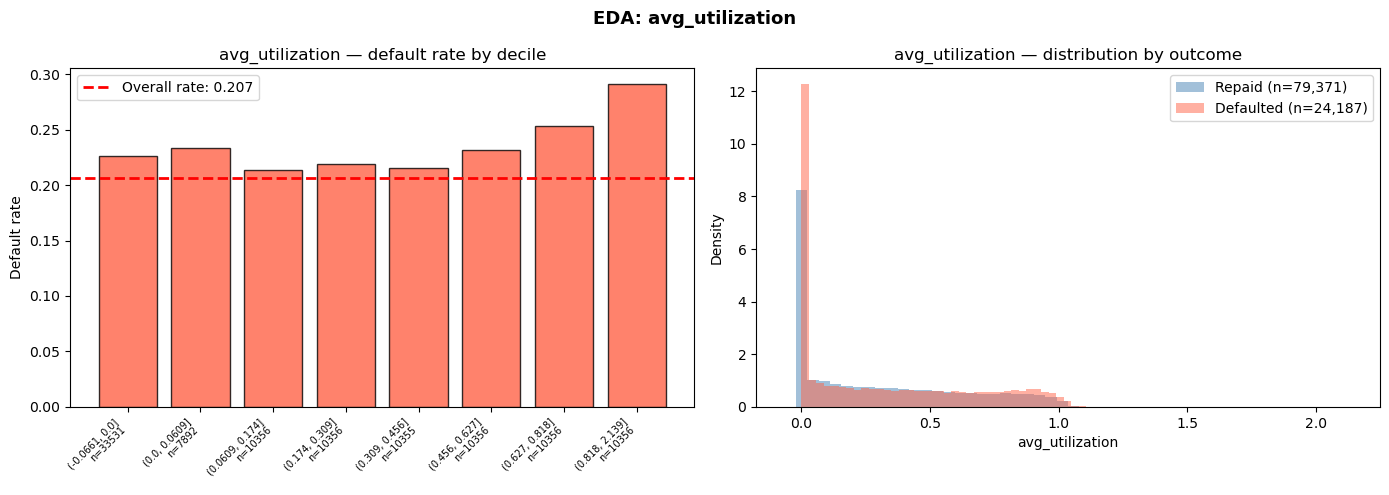


avg_utilization — default rate by decile:
            decile  midpoint  default_rate    count
0   (-0.0661, 0.0]  0.000000      0.226596  33531.0
1    (0.0, 0.0609]  0.023816      0.233528   7892.0
2  (0.0609, 0.174]  0.113241      0.213499  10356.0
3   (0.174, 0.309]  0.240647      0.219293  10356.0
4   (0.309, 0.456]  0.380253      0.215451  10355.0
5   (0.456, 0.627]  0.536833      0.231846  10356.0
6   (0.627, 0.818]  0.722627      0.253090  10356.0
7   (0.818, 2.139]  0.911835      0.290749  10356.0
  Max spread: 0.291 - 0.213 = 0.077pp
Max spread: 0.0772499034376207 Default signal strength: Moderate — worth rebinning or adding as supporting node



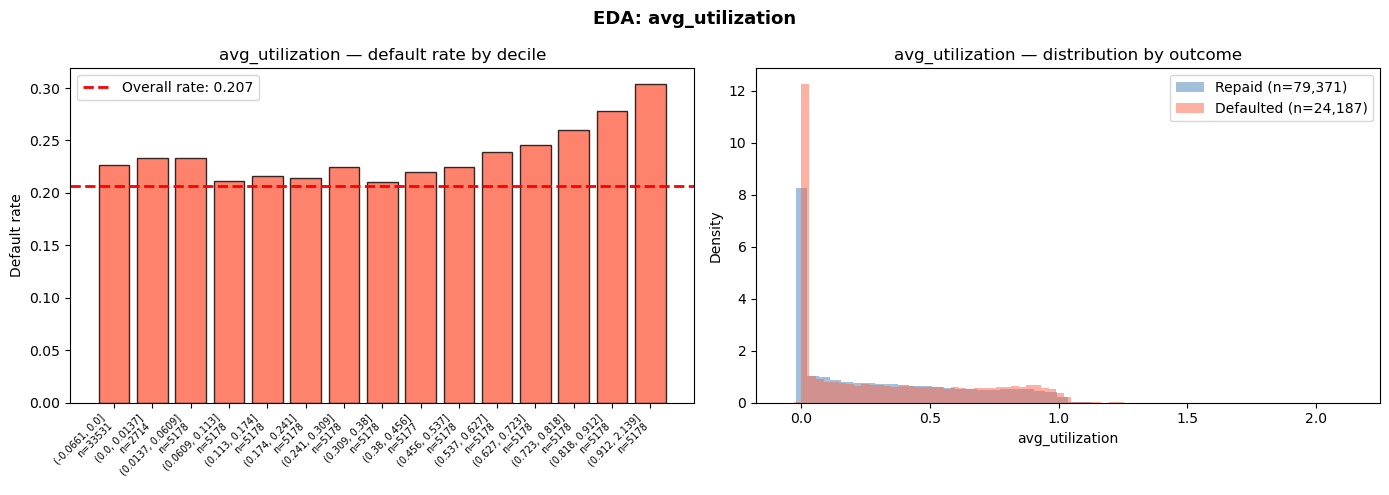


avg_utilization — default rate by decile:
              decile  midpoint  default_rate    count
0     (-0.0661, 0.0]  0.000000      0.226596  33531.0
1      (0.0, 0.0137]  0.003959      0.233604   2714.0
2   (0.0137, 0.0609]  0.035852      0.233488   5178.0
3    (0.0609, 0.113]  0.086224      0.211085   5178.0
4     (0.113, 0.174]  0.142842      0.215913   5178.0
5     (0.174, 0.241]  0.206144      0.213982   5178.0
6     (0.241, 0.309]  0.273790      0.224604   5178.0
7      (0.309, 0.38]  0.344352      0.210699   5178.0
8      (0.38, 0.456]  0.417327      0.220205   5177.0
9     (0.456, 0.537]  0.496273      0.224990   5178.0
10    (0.537, 0.627]  0.580459      0.238702   5178.0
11    (0.627, 0.723]  0.673796      0.246041   5178.0
12    (0.723, 0.818]  0.771348      0.260139   5178.0
13    (0.818, 0.912]  0.864824      0.277907   5178.0
14    (0.912, 2.139]  0.962131      0.303592   5178.0
  Max spread: 0.304 - 0.211 = 0.093pp
Max spread: 0.09289300888373889 Default signal strength

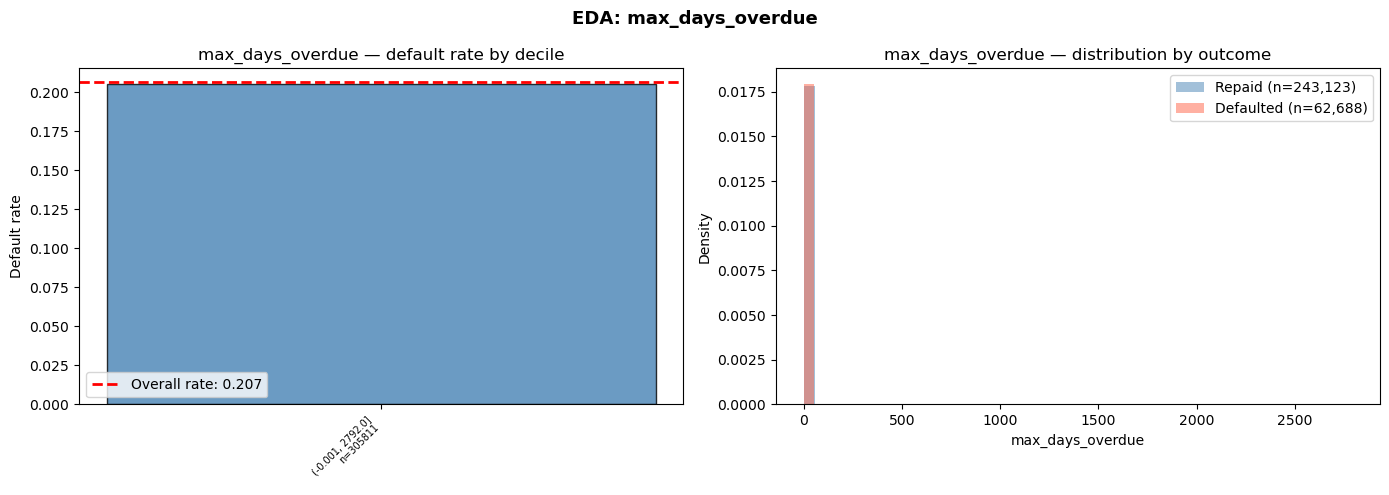


max_days_overdue — default rate by decile:
             decile  midpoint  default_rate     count
0  (-0.001, 2792.0]       0.0      0.204989  305811.0
  Max spread: 0.205 - 0.205 = 0.000pp
Max spread: 0.0 Default signal strength: Drop     — confirmed no signal



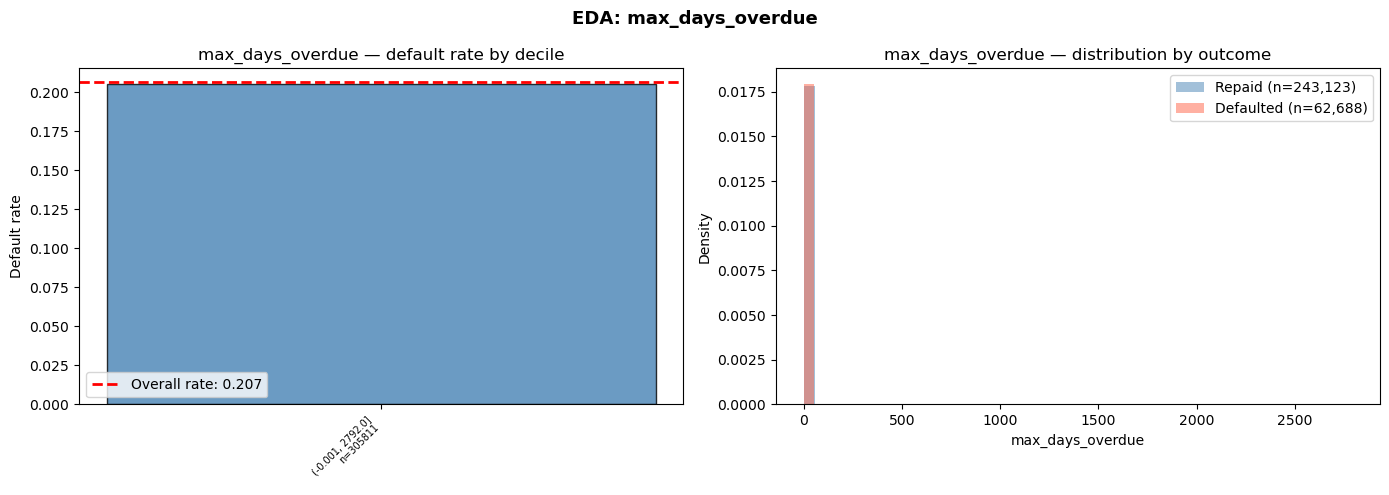


max_days_overdue — default rate by decile:
             decile  midpoint  default_rate     count
0  (-0.001, 2792.0]       0.0      0.204989  305811.0
  Max spread: 0.205 - 0.205 = 0.000pp
Max spread: 0.0 Default signal strength: Drop     — confirmed no signal


────────────────────────────────────────


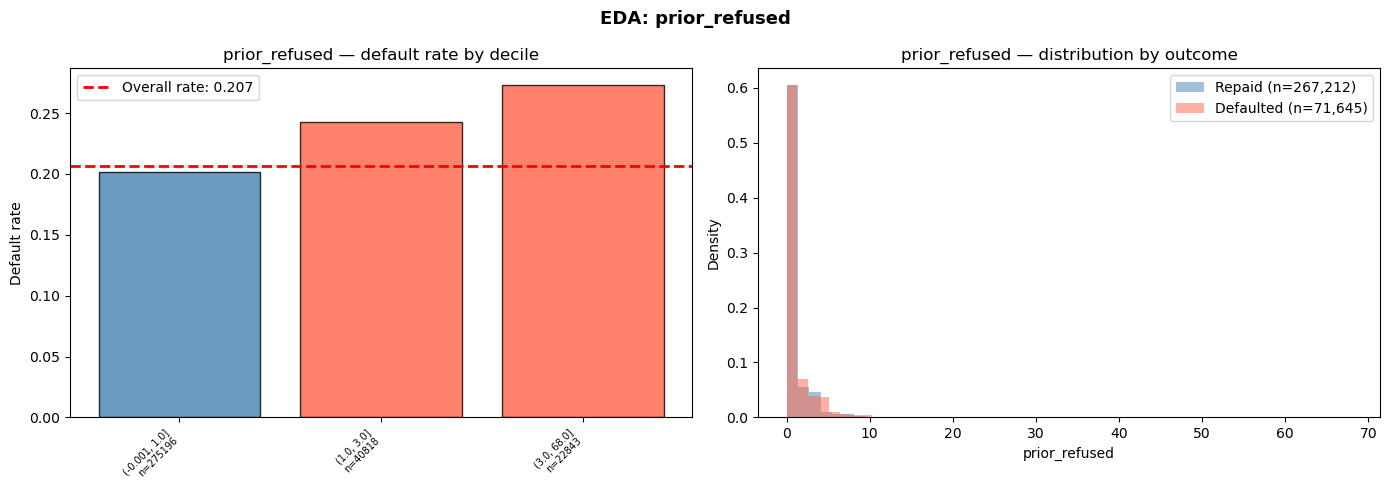


prior_refused — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.201685  275196.0
1     (1.0, 3.0]       2.0      0.242638   40818.0
2    (3.0, 68.0]       5.0      0.273081   22843.0
  Max spread: 0.273 - 0.202 = 0.071pp
Max spread: 0.07139612489531738 Default signal strength: Moderate — worth rebinning or adding as supporting node



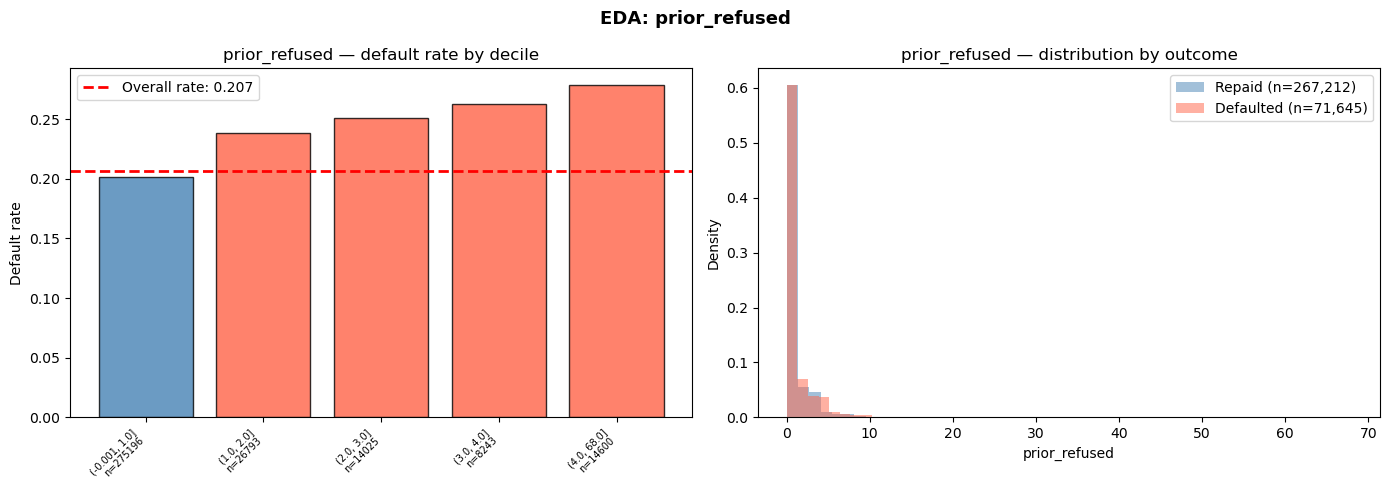


prior_refused — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       0.0      0.201685  275196.0
1     (1.0, 2.0]       2.0      0.238197   26793.0
2     (2.0, 3.0]       3.0      0.251123   14025.0
3     (3.0, 4.0]       4.0      0.263132    8243.0
4    (4.0, 68.0]       6.0      0.278699   14600.0
  Max spread: 0.279 - 0.202 = 0.077pp
Max spread: 0.07701328587326156 Default signal strength: Moderate — worth rebinning or adding as supporting node


────────────────────────────────────────


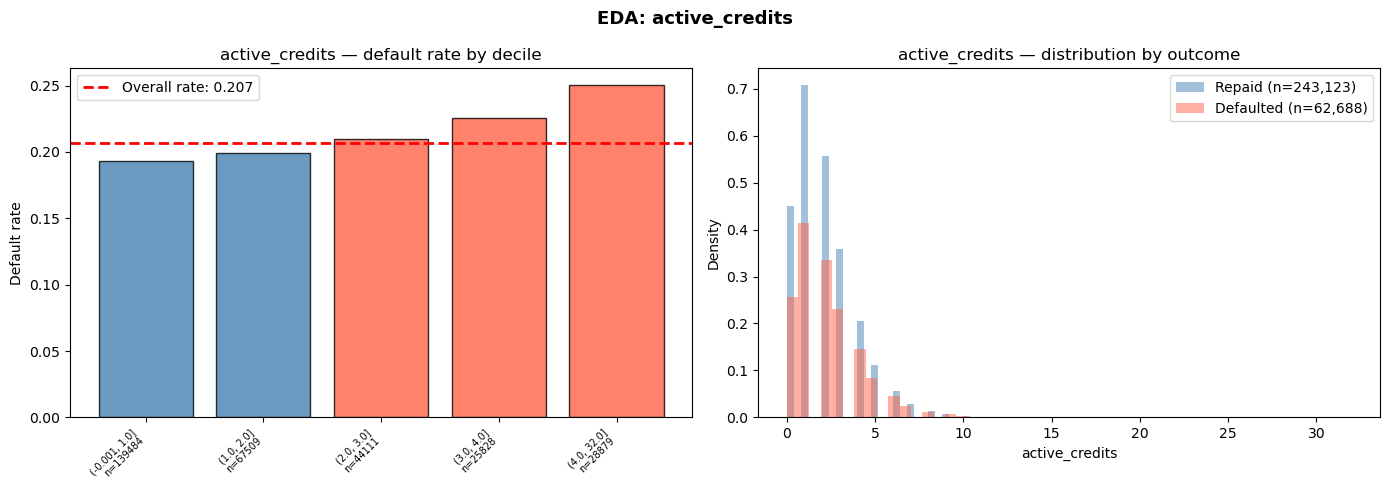


active_credits — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       1.0      0.193004  139484.0
1     (1.0, 2.0]       2.0      0.199559   67509.0
2     (2.0, 3.0]       3.0      0.209472   44111.0
3     (3.0, 4.0]       4.0      0.225414   25828.0
4    (4.0, 32.0]       6.0      0.250459   28879.0
  Max spread: 0.250 - 0.193 = 0.057pp
Max spread: 0.05745459536338854 Default signal strength: Moderate — worth rebinning or adding as supporting node



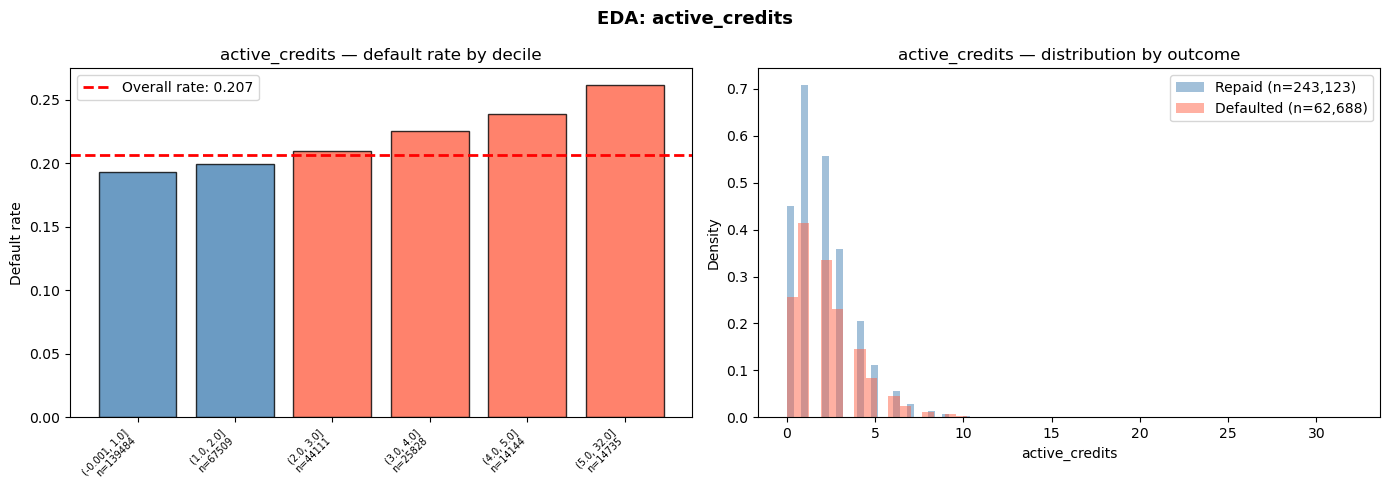


active_credits — default rate by decile:
          decile  midpoint  default_rate     count
0  (-0.001, 1.0]       1.0      0.193004  139484.0
1     (1.0, 2.0]       2.0      0.199559   67509.0
2     (2.0, 3.0]       3.0      0.209472   44111.0
3     (3.0, 4.0]       4.0      0.225414   25828.0
4     (4.0, 5.0]       5.0      0.238829   14144.0
5    (5.0, 32.0]       7.0      0.261622   14735.0
  Max spread: 0.262 - 0.193 = 0.069pp
Max spread: 0.06861777292557764 Default signal strength: Moderate — worth rebinning or adding as supporting node

CATEGORICAL FEATURES

────────────────────────────────────────


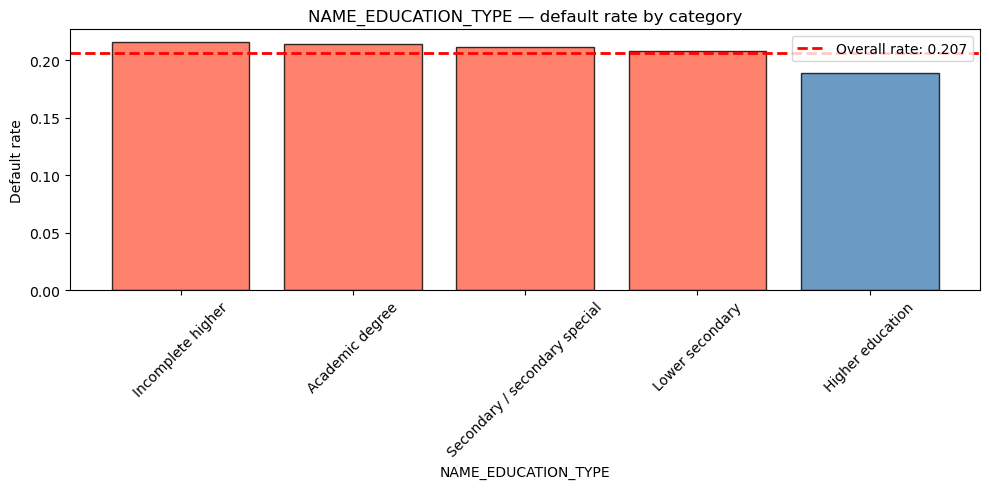


NAME_EDUCATION_TYPE — default rate by category:
             NAME_EDUCATION_TYPE  default_rate     count
2              Incomplete higher      0.216315   12001.0
0                Academic degree      0.214634     205.0
4  Secondary / secondary special      0.212030  252379.0
3                Lower secondary      0.207877    4291.0
1               Higher education      0.189119   87379.0
  Max spread: 0.027pp Default signal strength: Skip     — noise level, not worth adding


────────────────────────────────────────


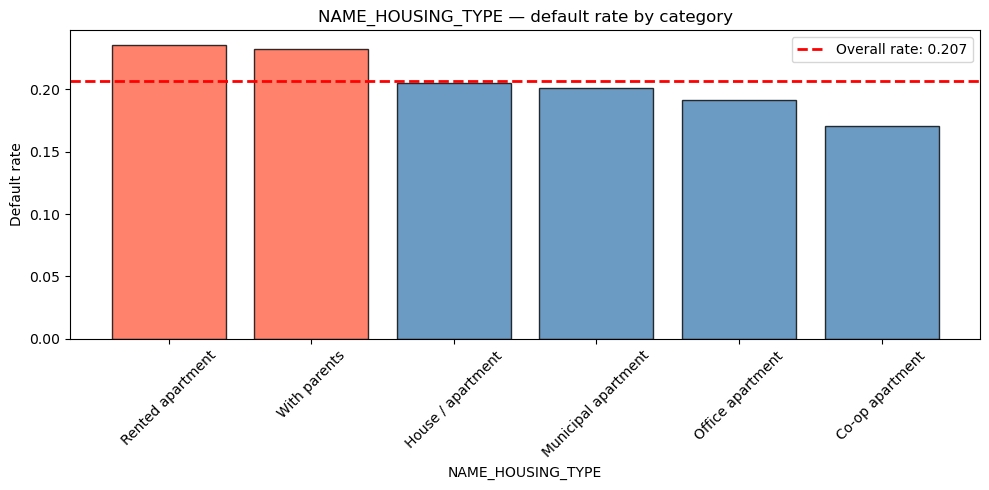


NAME_HOUSING_TYPE — default rate by category:
     NAME_HOUSING_TYPE  default_rate     count
4     Rented apartment      0.235578    5599.0
5         With parents      0.232517   17074.0
1    House / apartment      0.205101  316513.0
2  Municipal apartment      0.200937   12800.0
3     Office apartment      0.191468    3024.0
0      Co-op apartment      0.170281    1245.0
  Max spread: 0.065pp Default signal strength: Moderate — worth rebinning or adding as supporting node


────────────────────────────────────────


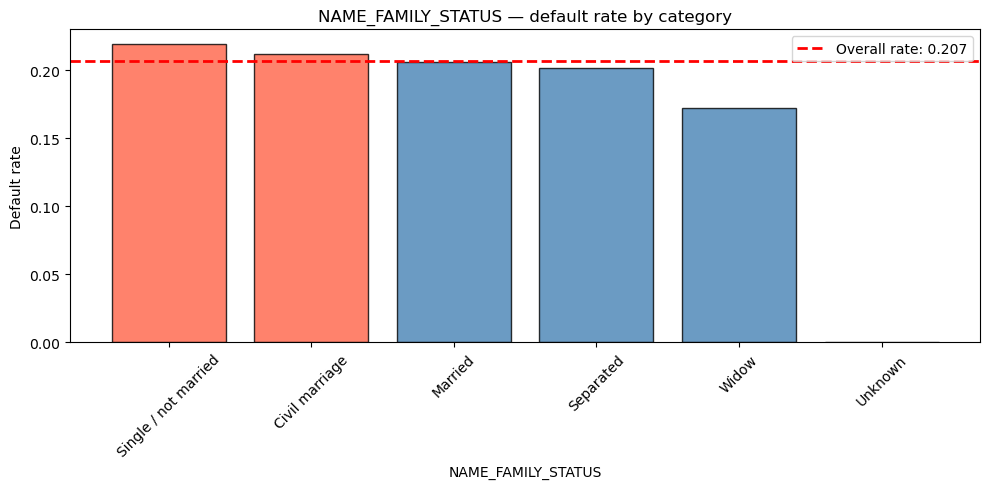


NAME_FAMILY_STATUS — default rate by category:
     NAME_FAMILY_STATUS  default_rate     count
3  Single / not married      0.218998   52480.0
0        Civil marriage      0.212187   34036.0
1               Married      0.206077  228715.0
2             Separated      0.201320   22725.0
5                 Widow      0.171941   18297.0
4               Unknown      0.000000       2.0
  Max spread: 0.047pp Default signal strength: Weak     — marginal value, only add if CPT cost is low


────────────────────────────────────────


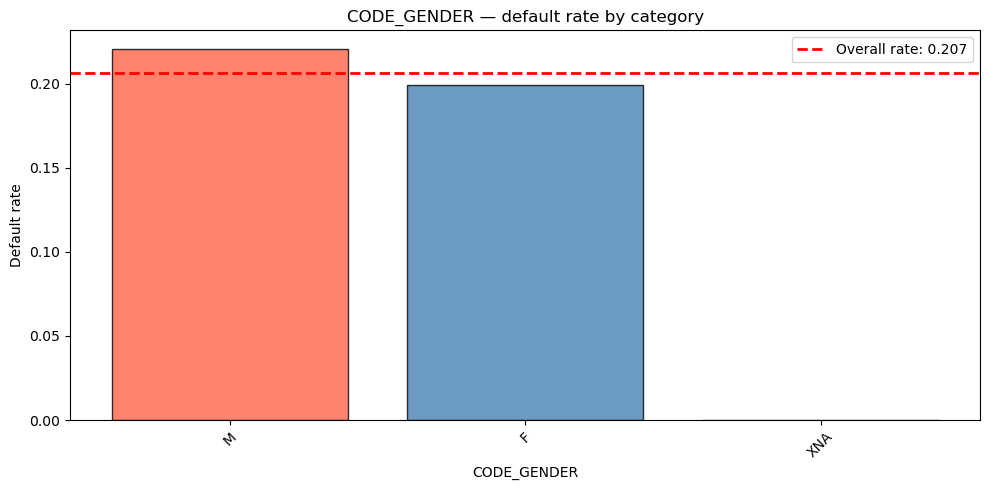


CODE_GENDER — default rate by category:
  CODE_GENDER  default_rate     count
1           M      0.220607  121125.0
0           F      0.199246  235126.0
2         XNA      0.000000       4.0
  Max spread: 0.021pp Default signal strength: Skip     — noise level, not worth adding


────────────────────────────────────────


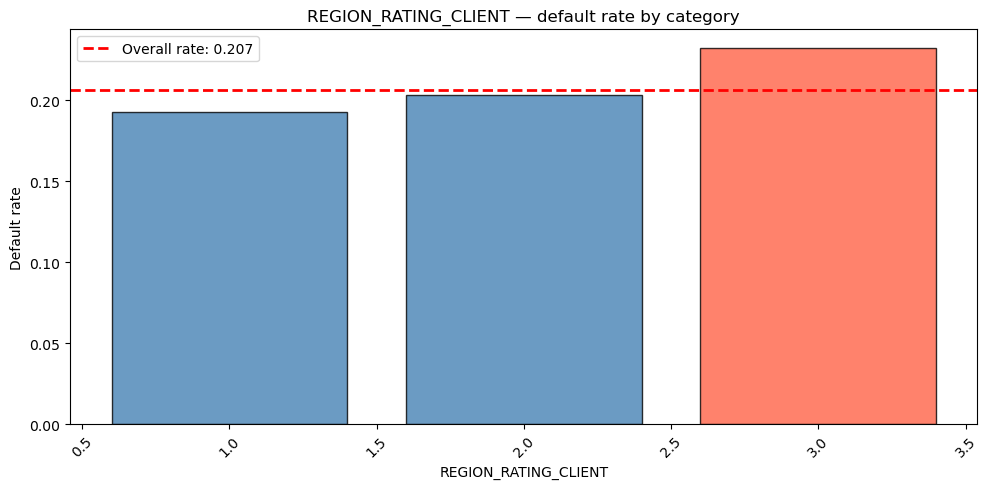


REGION_RATING_CLIENT — default rate by category:
   REGION_RATING_CLIENT  default_rate     count
2                     3      0.232155   55954.0
1                     2      0.203030  262340.0
0                     1      0.192724   37961.0
  Max spread: 0.039pp Default signal strength: Weak     — marginal value, only add if CPT cost is low



In [85]:
#labeled = raw_df[['SK_ID_CURR', 'LoanOutcome']].dropna(subset=['LoanOutcome']).copy()
labeled = raw_df[['SK_ID_CURR','LoanOutcome']].dropna(subset=['LoanOutcome']).copy()
overall_default_rate = labeled['LoanOutcome'].eq('Defaulted').mean()

def get_verdict(max_spread):
    """Return verdict string based on max spread value."""
    # Define thresholds as (minimum_spread, verdict) in descending order
    verdict_thresholds = [
        (0.10, 'Strong   — worth adding as direct LoanOutcome parent'),
        (0.05, 'Moderate — worth rebinning or adding as supporting node'),
        (0.03, 'Weak     — marginal value, only add if CPT cost is low'),
        (0.00, 'Skip     — noise level, not worth adding'),
    ]

    if max_spread == 0:
        return 'Drop     — confirmed no signal'
    for min_threshold, verdict in verdict_thresholds:
        if max_spread >= min_threshold:
            return verdict
    return 'Drop     — confirmed no signal'

# ── CONTINUOUS: decile default rate plot ─────────────────────────────────────
def plot_decile_default_rate(df, col, labeled, overall_rate, n_quantiles=10):
    """
    For each decile of a continuous variable, shows the default rate.
    The red dashed line is the overall default rate — bars above it
    are higher risk, bars below are lower risk.
    The shape of the bars tells you where to draw bin boundaries.
    """
    diag = df[['SK_ID_CURR', col]].merge(labeled, on='SK_ID_CURR').dropna(subset=[col])
    
    try:
        diag['decile'] = pd.qcut(diag[col], q=n_quantiles, duplicates='drop')
    except ValueError:
        print(f"  Skipping {col} — too many duplicate values for {n_quantiles} quantiles")
        return None
    
    rate_by_decile = diag.groupby('decile', observed=True).apply(
        lambda x: pd.Series({
            'default_rate': x['LoanOutcome'].eq('Defaulted').mean(),
            'count':        len(x),
            'midpoint':     x[col].median()
        })
    ).reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left — default rate by decile
    colors = ['tomato' if r > overall_rate else 'steelblue' 
              for r in rate_by_decile['default_rate']]
    axes[0].bar(range(len(rate_by_decile)), rate_by_decile['default_rate'],
                color=colors, edgecolor='black', alpha=0.8)
    axes[0].axhline(y=overall_rate, color='red', linestyle='--', 
                    linewidth=2, label=f'Overall rate: {overall_rate:.3f}')
    axes[0].set_xticks(range(len(rate_by_decile)))
    axes[0].set_xticklabels([f"{row['decile']}\nn={int(row['count'])}" 
                              for _, row in rate_by_decile.iterrows()], 
                             rotation=45, ha='right', fontsize=7)
    axes[0].set_title(f'{col} — default rate by decile')
    axes[0].set_ylabel('Default rate')
    axes[0].legend()
    
    # Right — overlapping density by outcome
    for outcome, color in [('Repaid', 'steelblue'), ('Defaulted', 'tomato')]:
        subset = diag[diag['LoanOutcome'] == outcome][col]
        axes[1].hist(subset, bins=50, alpha=0.5, color=color,
                     label=f'{outcome} (n={len(subset):,})', density=True)
    axes[1].set_title(f'{col} — distribution by outcome')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Density')
    axes[1].legend()
    
    plt.suptitle(f'EDA: {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print the decile table so you can see exact bin boundaries
    max_spread = rate_by_decile['default_rate'].max() - rate_by_decile['default_rate'].min()
    print(f"\n{col} — default rate by decile:")
    print(rate_by_decile[['decile', 'midpoint', 'default_rate', 'count']].to_string())
    print(f"  Max spread: {rate_by_decile['default_rate'].max():.3f} - "
          f"{rate_by_decile['default_rate'].min():.3f} = "
          f"{rate_by_decile['default_rate'].max() - rate_by_decile['default_rate'].min():.3f}pp")
    print(f"Max spread: {max_spread} Default signal strength: {get_verdict(max_spread)}")                                                     
    print()
    
    return rate_by_decile

# ── CATEGORICAL: cross-tab default rate ──────────────────────────────────────
def plot_categorical_default_rate(df, col, labeled, overall_rate, min_count=100):
    """
    For categorical columns — bar chart of default rate per category.
    """
    diag = df[['SK_ID_CURR', col]].merge(labeled, on='SK_ID_CURR').dropna(subset=[col])
    
    rate_by_cat = diag.groupby(col).apply(
        lambda x: pd.Series({
            'default_rate': x['LoanOutcome'].eq('Defaulted').mean(),
            'count':        len(x)
        })
    ).reset_index().sort_values('default_rate', ascending=False)
    
    
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['tomato' if r > overall_rate else 'steelblue' 
              for r in rate_by_cat['default_rate']]
    ax.bar(rate_by_cat[col], rate_by_cat['default_rate'],
           color=colors, edgecolor='black', alpha=0.8)
    ax.axhline(y=overall_rate, color='red', linestyle='--',
               linewidth=2, label=f'Overall rate: {overall_rate:.3f}')
    ax.set_title(f'{col} — default rate by category')
    ax.set_xlabel(col)
    ax.set_ylabel('Default rate')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    
    print(f"\n{col} — default rate by category:")
    print(rate_by_cat.to_string())
    reliable = rate_by_cat[rate_by_cat['count'] > min_count]
    spread = reliable['default_rate'].max() - reliable['default_rate'].min()
    print(f"  Max spread: {spread:.3f}pp Default signal strength: {get_verdict(spread)}")
    print()
    return rate_by_cat


# ── RUN ALL CANDIDATES ───────────────────────────────────────────────────────
continuous = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_CREDIT', 'AMT_ANNUITY',
              'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DEF_30_CNT_SOCIAL_CIRCLE',
              'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_MON',
              'AMT_REQ_CREDIT_BUREAU_QRT', 'on_time_rate', 'avg_utilization',
              'max_days_overdue', 'prior_refused', 'active_credits']

categorical = ['NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE',
               'NAME_FAMILY_STATUS', 'CODE_GENDER', 'REGION_RATING_CLIENT']

print("=" * 60)
print("CONTINUOUS FEATURES")
print("=" * 60)
results_continuous = {}
for col in continuous:
    if col in raw_df.columns:
        print(f"\n{'─'*40}")
        results_continuous[col] = plot_decile_default_rate(raw_df, col, labeled, overall_default_rate, n_quantiles=10)
        results_continuous[col] = plot_decile_default_rate(raw_df, col, labeled, overall_default_rate, n_quantiles=20)
    else:
        print(f"  {col} not found in dataframe")

print("=" * 60)
print("CATEGORICAL FEATURES")
print("=" * 60)
results_categorical = {}
for col in categorical:
    if col in raw_df.columns:
        print(f"\n{'─'*40}")
        results_categorical[col] = plot_categorical_default_rate(
            raw_df, col, labeled, overall_default_rate
        )
    else:
        print(f"  {col} not found in dataframe")


In [93]:
def assign_label(rate, baseline):
        distance = rate - baseline
        if   distance >= 0.05:   return 'VeryHigh'
        elif distance >= 0.03:   return 'High'
        elif distance >= 0.01:   return 'MedHigh'
        elif distance >= -0.01:  return 'Medium'
        elif distance >= -0.03:  return 'MedLow'
        elif distance >= -0.05:  return 'Low'
        else:                    return 'VeryLow'

def auto_bin(df, col, labeled, baseline=0.206, 
             min_count=1000, max_bins=6, n_quantiles=20):
    """
    Automatically determines optimal bin boundaries and labels
    for a continuous feature based on default rate patterns.
    
    Steps:
        1. Create fine-grained quantile buckets
        2. Filter out sparse buckets
        3. Find natural breakpoints where rate changes significantly
        4. Merge flat adjacent buckets
        5. Assign labels based on distance from baseline
        6. Return bin boundaries and labels
    
    Parameters:
        df          : DataFrame containing SK_ID_CURR and col
        col         : column name to analyze
        labeled     : DataFrame with SK_ID_CURR and LoanOutcome
        baseline    : overall default rate (default 0.206)
        min_count   : minimum rows per bucket (default 1000)
        max_bins    : maximum number of final bins (default 6)
        n_quantiles : granularity of initial analysis (default 20)
    
    Returns:
        dict with bins, labels, rates, verdict and plot
    """
    # ── Step 1: Create fine quantile buckets ─────────────────────────────
    diag = df[['SK_ID_CURR', col]].merge(labeled, on='SK_ID_CURR')\
                                   .dropna(subset=[col])
    
    try:
        diag['bucket'] = pd.qcut(diag[col], q=n_quantiles, 
                                  duplicates='drop')
    except ValueError as e:
        print(f"Cannot create {n_quantiles} quantiles for {col}: {e}")
        return None

    rate_table = diag.groupby('bucket', observed=True).apply(
        lambda x: pd.Series({
            'default_rate': x['LoanOutcome'].eq('Defaulted').mean(),
            'count':        len(x),
            'min_val':      x[col].min(),
            'max_val':      x[col].max(),
            'midpoint':     x[col].median()
        })
    ).reset_index().sort_values('min_val')

    # ── Step 2: Filter sparse buckets ────────────────────────────────────
    reliable = rate_table[rate_table['count'] >= min_count].copy()
    excluded = rate_table[rate_table['count'] <  min_count]
    
    if len(excluded) > 0:
        print(f"  Excluded {len(excluded)} sparse buckets "
              f"(count < {min_count})")

    if reliable.empty:
        print(f"  No reliable buckets for {col}")
        return None

    # ── Step 3: Find natural breakpoints ─────────────────────────────────
    # Compute rate change between adjacent buckets
    reliable['rate_change'] = reliable['default_rate'].diff().abs()
    reliable['direction']   = reliable['default_rate'].diff().apply(
        lambda x: 'up' if x > 0 else ('down' if x < 0 else 'flat')
    )
    
    # Find direction changes (inflection points)
    reliable['prev_direction'] = reliable['direction'].shift(1)
    reliable['inflection']     = (
        reliable['direction'] != reliable['prev_direction']
    ) & (reliable['direction'] != 'flat')
    
    # Find large rate jumps (above threshold)
    jump_threshold = 0.02  # 2pp change between adjacent buckets
    reliable['big_jump'] = reliable['rate_change'] > jump_threshold
    
    # Candidate breakpoints are either inflections or big jumps
    breakpoints = reliable[
        reliable['inflection'] | reliable['big_jump']
    ]['min_val'].tolist()
    
    print(f"\n  Natural breakpoints found at: "
          f"{[round(b, 0) for b in breakpoints]}")

    # ── Step 4: Merge flat adjacent buckets ──────────────────────────────
    # Group consecutive buckets with similar rates into single bins
    # Rate difference threshold for merging
    merge_threshold = 0.01  # merge buckets within 1pp of each other
    
    bins      = [reliable['min_val'].min()]  # start with minimum value
    bin_rates = []
    
    current_group      = [reliable.iloc[0]]
    current_group_rate = reliable.iloc[0]['default_rate']
    
    for _, row in reliable.iloc[1:].iterrows():
        rate_diff = abs(row['default_rate'] - current_group_rate)
        
        if rate_diff <= merge_threshold:
            # Similar rate — merge into current group
            current_group.append(row)
        else:
            # Different rate — close current group, start new one
            group_df   = pd.DataFrame(current_group)
            bins.append(group_df['max_val'].max())
            bin_rates.append(group_df['default_rate'].mean())
            current_group      = [row]
            current_group_rate = row['default_rate']
    
    # Close the last group
    group_df = pd.DataFrame(current_group)
    bins.append(group_df['max_val'].max())
    bin_rates.append(group_df['default_rate'].mean())

    # ── Enforce max_bins limit ────────────────────────────────────────────
    while len(bin_rates) > max_bins:
        # Find the two adjacent bins with the smallest rate difference
        # and merge them
        diffs = [abs(bin_rates[i+1] - bin_rates[i]) 
                 for i in range(len(bin_rates)-1)]
        merge_idx = diffs.index(min(diffs))
        
        # Merge bin merge_idx and merge_idx+1
        merged_rate = (bin_rates[merge_idx] + bin_rates[merge_idx+1]) / 2
        bin_rates.pop(merge_idx)
        bin_rates.pop(merge_idx)
        bin_rates.insert(merge_idx, merged_rate)
        bins.pop(merge_idx + 1)

    # ── Step 5: Assign labels based on distance from baseline ────────────
        
    labels = [assign_label(rate, baseline) for rate in bin_rates]

    # ── Step 6: Build results and plot ───────────────────────────────────
    spread = max(bin_rates) - min(bin_rates)
    results = {
        'feature'   : col,
        'bins'      : bins,
        'labels'    : labels,
        'bin_rates' : bin_rates,
        'n_bins'    : len(labels),
        'spread'    : spread,
        'verdict'   : get_verdict(spread)
    }

    # Print summary
    print(f"\n  Recommended binning for {col}:")
    print(f"  {'Bin range':<30} {'Rate':>8}  {'Label'}")
    print(f"  {'─'*55}")
    for i, (rate, label) in enumerate(zip(bin_rates, labels)):
        lo = bins[i]
        hi = bins[i+1]
        print(f"  ({lo:>10.0f} → {hi:>10.0f}]  "
              f"{rate:>6.3f}  {label}")
    print(f"\n  Spread:  {results['spread']*100:.1f}pp")
    print(f"  Verdict: {results['verdict']}")
    print(f"\n  pd.cut code:")
    print(f"  bins  = {[round(b, 2) for b in bins]}")
    print(f"  labels= {labels}")

    # Plot
    _plot_auto_bins(reliable, bins, bin_rates, labels, col, baseline)
    
    return results


def _plot_auto_bins(rate_table, bins, bin_rates, labels, col, baseline):
    """Plot the fine-grained rates with proposed bin boundaries overlaid."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left — fine grained rates with bin boundaries
    axes[0].bar(range(len(rate_table)), rate_table['default_rate'],
                color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].axhline(y=baseline, color='red', linestyle='--',
                    linewidth=2, label=f'Baseline: {baseline:.3f}')
    
    # Overlay proposed bin boundaries
    bin_midpoints = rate_table['midpoint'].values
    for boundary in bins[1:-1]:
        # Find closest bucket to boundary
        closest_idx = (rate_table['min_val'] - boundary).abs().argmin()
        axes[0].axvline(x=closest_idx, color='orange', 
                        linestyle='--', linewidth=2, alpha=0.8)
    
    axes[0].set_title(f'{col} — fine grained rates\n'
                      f'(orange lines = proposed boundaries)')
    axes[0].set_ylabel('Default rate')
    axes[0].legend()
    
    # Right — proposed bins with labels
    colors_map = {
        'VeryHigh': '#d32f2f',
        'High':     '#f57c00',
        'MedHigh':  '#fbc02d',
        'Medium':   '#7986cb',
        'MedLow':   '#4db6ac',
        'Low':      '#81c784',
        'VeryLow':  '#388e3c'
    }
    bar_colors = [colors_map.get(l, 'steelblue') for l in labels]
    
    axes[1].bar(range(len(bin_rates)), bin_rates,
                color=bar_colors, edgecolor='black', alpha=0.8)
    axes[1].axhline(y=baseline, color='red', linestyle='--',
                    linewidth=2, label=f'Baseline: {baseline:.3f}')
    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels, rotation=45, ha='right')
    axes[1].set_title(f'{col} — proposed bins with labels')
    axes[1].set_ylabel('Default rate')
    axes[1].legend()
    
    # Add rate annotations
    for i, rate in enumerate(bin_rates):
        axes[1].text(i, rate + 0.002, f'{rate:.3f}', 
                     ha='center', va='bottom', fontsize=9)
    
    plt.suptitle(f'Auto-binning: {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


AUTO-BINNING: DAYS_BIRTH

  Natural breakpoints found at: [-23203.0, -22185.0, -21314.0, -20471.0, -19675.0, -16466.0, -15754.0, -13793.0, -13147.0, -12424.0, -11707.0, -10293.0, -9417.0]

  Recommended binning for DAYS_BIRTH:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (    -25229 →     -23204]   0.174  Low
  (    -23204 →     -19676]   0.185  MedLow
  (    -19676 →     -18031]   0.197  Medium
  (    -18031 →     -13148]   0.208  Medium
  (    -13148 →     -11015]   0.225  MedHigh
  (    -11015 →      -7338]   0.232  MedHigh

  Spread:  5.8pp
  Verdict: Moderate — worth rebinning or adding as supporting node

  pd.cut code:
  bins  = [np.float64(-25229.0), np.float64(-23204.0), np.float64(-19676.0), np.float64(-18031.0), np.float64(-13148.0), np.float64(-11015.0), np.float64(-7338.0)]
  labels= ['Low', 'MedLow', 'Medium', 'Medium', 'MedHigh', 'MedHigh']


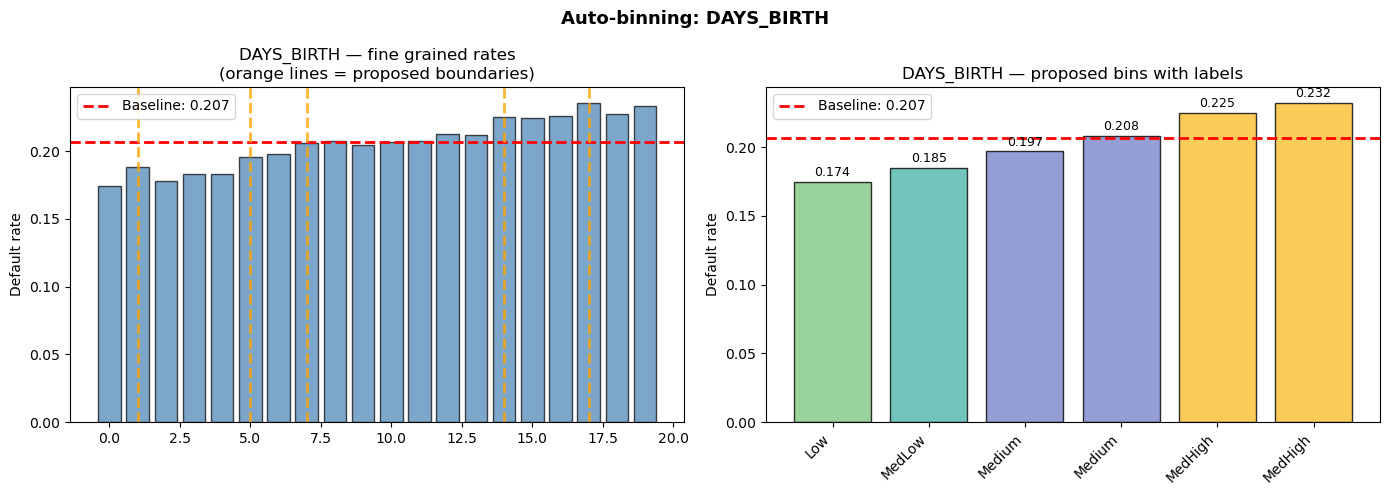


AUTO-BINNING: DAYS_EMPLOYED

  Natural breakpoints found at: [-6739.0, -2780.0, -2379.0, -2011.0, -1708.0, -1458.0, -830.0, -646.0, -461.0, -141.0]

  Recommended binning for DAYS_EMPLOYED:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (    -17912 →      -6740]   0.173  Low
  (     -6740 →      -3893]   0.191  MedLow
  (     -3893 →      -2012]   0.203  Medium
  (     -2012 →      -1459]   0.217  MedHigh
  (     -1459 →       -142]   0.224  MedHigh
  (      -142 →     365243]   0.191  MedLow

  Spread:  5.1pp
  Verdict: Moderate — worth rebinning or adding as supporting node

  pd.cut code:
  bins  = [np.float64(-17912.0), np.float64(-6740.0), np.float64(-3893.0), np.float64(-2012.0), np.float64(-1459.0), np.float64(-142.0), np.float64(365243.0)]
  labels= ['Low', 'MedLow', 'Medium', 'MedHigh', 'MedHigh', 'MedLow']


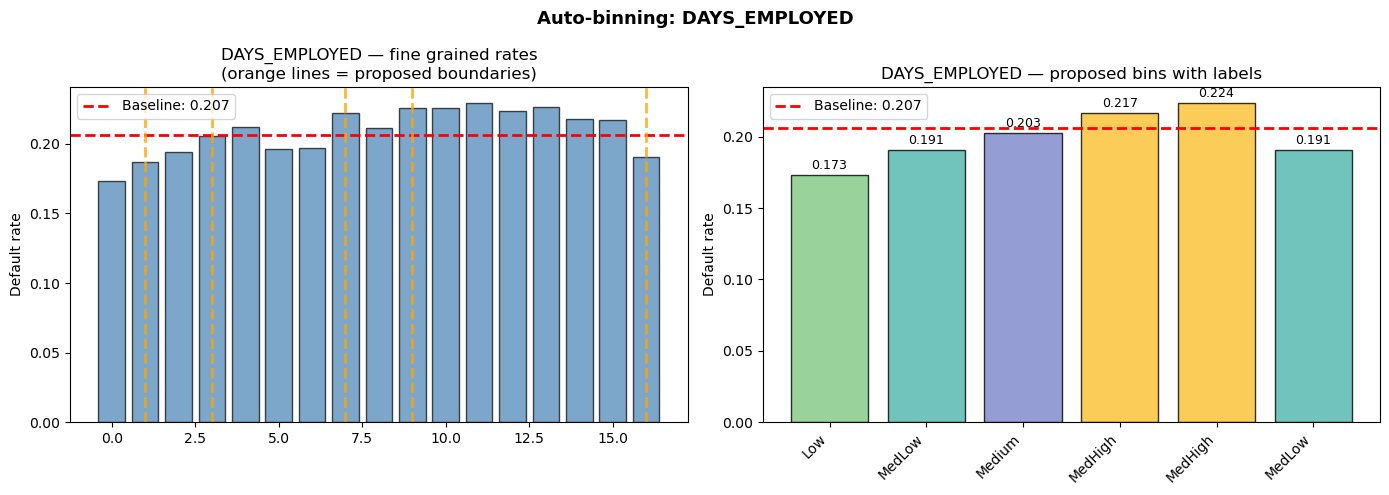


AUTO-BINNING: AMT_CREDIT

  Natural breakpoints found at: [135122.0, 180580.0, 225171.0, 252022.0, 270036.0, 299493.0, 343840.0, 450040.0, 500427.0, 540360.0, 675040.0, 726318.0, 797814.0, 1007352.0, 1125090.0, 1350189.0]

  Recommended binning for AMT_CREDIT:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (     45000 →     252000]   0.223  MedHigh
  (    252000 →     270000]   0.171  Low
  (    270000 →     675000]   0.242  High
  (    675000 →    1125000]   0.169  Low
  (   1125000 →    1350000]   0.108  VeryLow
  (   1350000 →    4050000]   0.158  Low

  Spread:  13.4pp
  Verdict: Strong   — worth adding as direct LoanOutcome parent

  pd.cut code:
  bins  = [np.float64(45000.0), np.float64(252000.0), np.float64(270000.0), np.float64(675000.0), np.float64(1125000.0), np.float64(1350000.0), np.float64(4050000.0)]
  labels= ['MedHigh', 'Low', 'High', 'Low', 'VeryLow', 'Low']


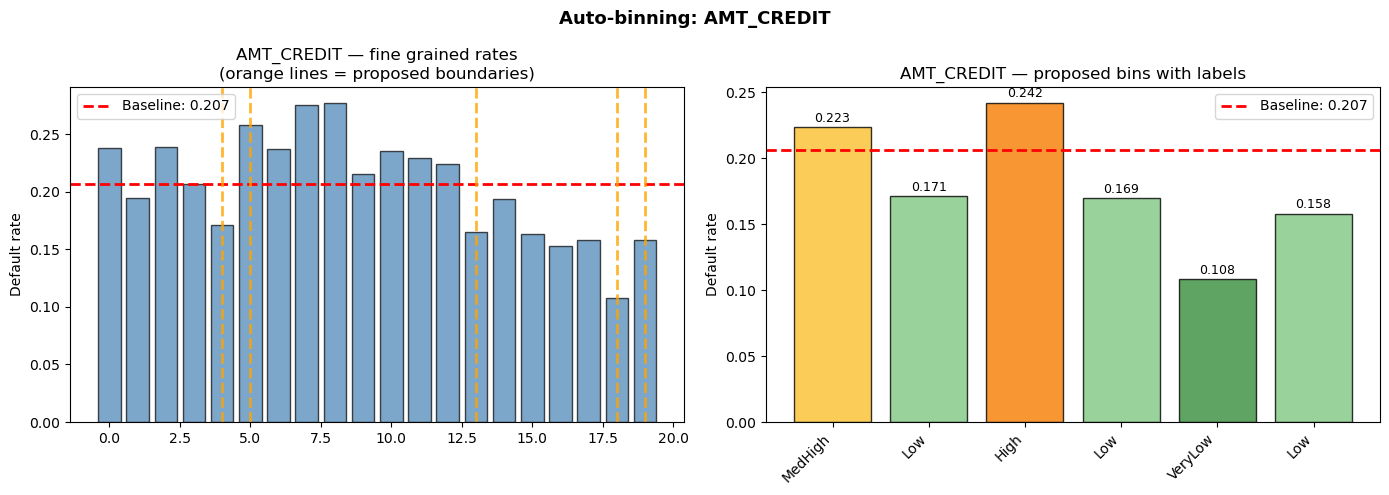


AUTO-BINNING: AMT_ANNUITY

  Natural breakpoints found at: [9004.0, 13486.0, 14949.0, 16736.0, 18441.0, 20264.0, 21946.0, 23544.0, 25083.0, 26514.0, 30303.0, 37804.0, 53919.0]

  Recommended binning for AMT_ANNUITY:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (      1616 →      14944]   0.167  Low
  (     14944 →      16731]   0.201  Medium
  (     16731 →      23540]   0.227  MedHigh
  (     23540 →      26510]   0.196  MedLow
  (     26510 →      53914]   0.219  MedHigh
  (     53914 →     258026]   0.257  VeryHigh

  Spread:  9.0pp
  Verdict: Moderate — worth rebinning or adding as supporting node

  pd.cut code:
  bins  = [np.float64(1615.5), np.float64(14944.5), np.float64(16731.0), np.float64(23539.5), np.float64(26509.5), np.float64(53914.5), np.float64(258025.5)]
  labels= ['Low', 'Medium', 'MedHigh', 'MedLow', 'MedHigh', 'VeryHigh']


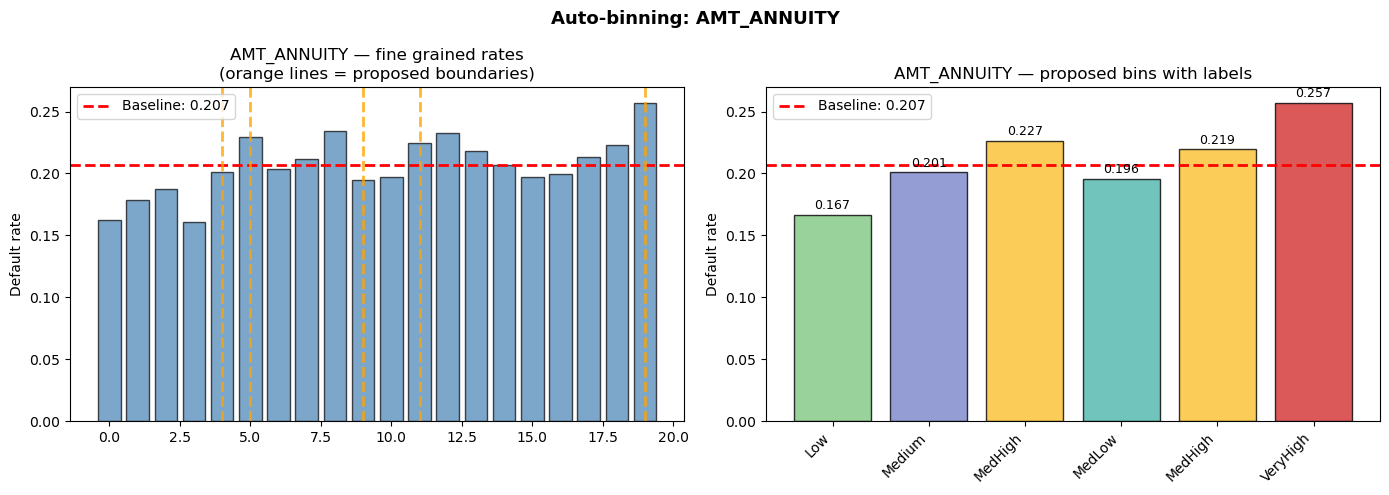


AUTO-BINNING: AMT_INCOME_TOTAL

  Natural breakpoints found at: [67568.0, 112550.0, 126063.0, 153130.0, 180090.0, 189148.0, 202806.0, 247622.0, 337545.0]

  Recommended binning for AMT_INCOME_TOTAL:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (     25650 →      81000]   0.178  MedLow
  (     81000 →      99000]   0.191  MedLow
  (     99000 →     135000]   0.207  Medium
  (    135000 →     180000]   0.217  MedHigh
  (    180000 →     189000]   0.193  MedLow
  (    189000 →  117000000]   0.215  Medium

  Spread:  3.9pp
  Verdict: Weak     — marginal value, only add if CPT cost is low

  pd.cut code:
  bins  = [np.float64(25650.0), np.float64(81000.0), np.float64(99000.0), np.float64(135000.0), np.float64(180000.0), np.float64(189000.0), np.float64(117000000.0)]
  labels= ['MedLow', 'MedLow', 'Medium', 'MedHigh', 'MedLow', 'Medium']


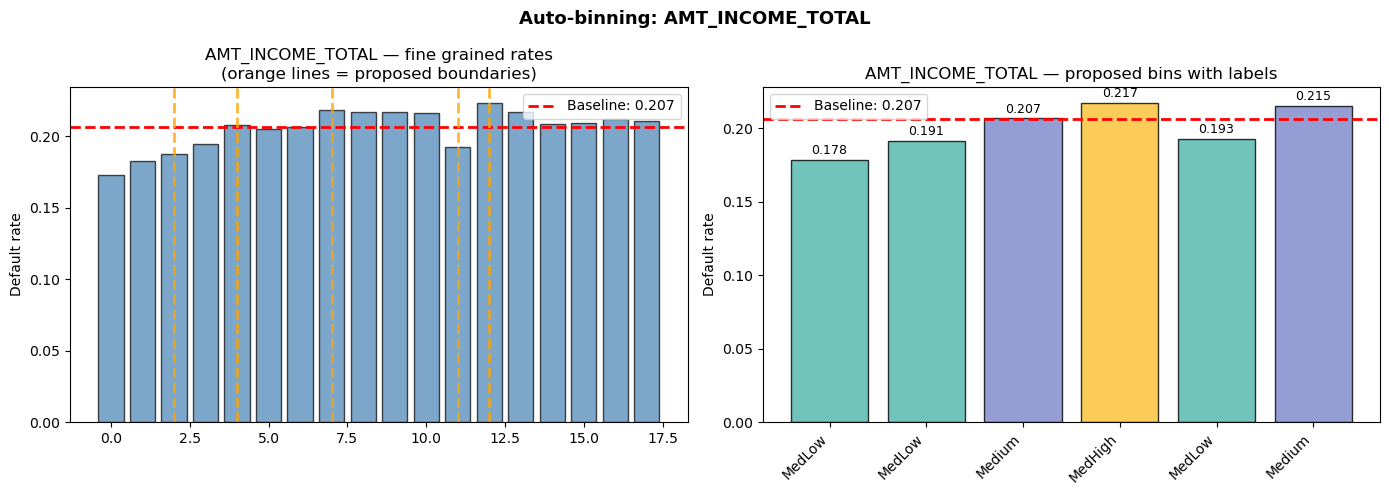


AUTO-BINNING: AMT_GOODS_PRICE

  Natural breakpoints found at: [136526.0, 171468.0, 202914.0, 225243.0, 234342.0, 272380.0, 307976.0, 362632.0, 450234.0, 454540.0, 495860.0, 594558.0, 675382.0, 778500.0, 900090.0, 1039316.0, 1305706.0]

  Recommended binning for AMT_GOODS_PRICE:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (     40500 →     171000]   0.250  High
  (    171000 →     270000]   0.201  Medium
  (    270000 →     450000]   0.261  VeryHigh
  (    450000 →     454500]   0.134  VeryLow
  (    454500 →     675000]   0.218  MedHigh
  (    675000 →    4050000]   0.138  VeryLow

  Spread:  12.7pp
  Verdict: Strong   — worth adding as direct LoanOutcome parent

  pd.cut code:
  bins  = [np.float64(40500.0), np.float64(171000.0), np.float64(270000.0), np.float64(450000.0), np.float64(454500.0), np.float64(675000.0), np.float64(4050000.0)]
  labels= ['High', 'Medium', 'VeryHigh', 'VeryLow', 'MedHigh', 'VeryLow']


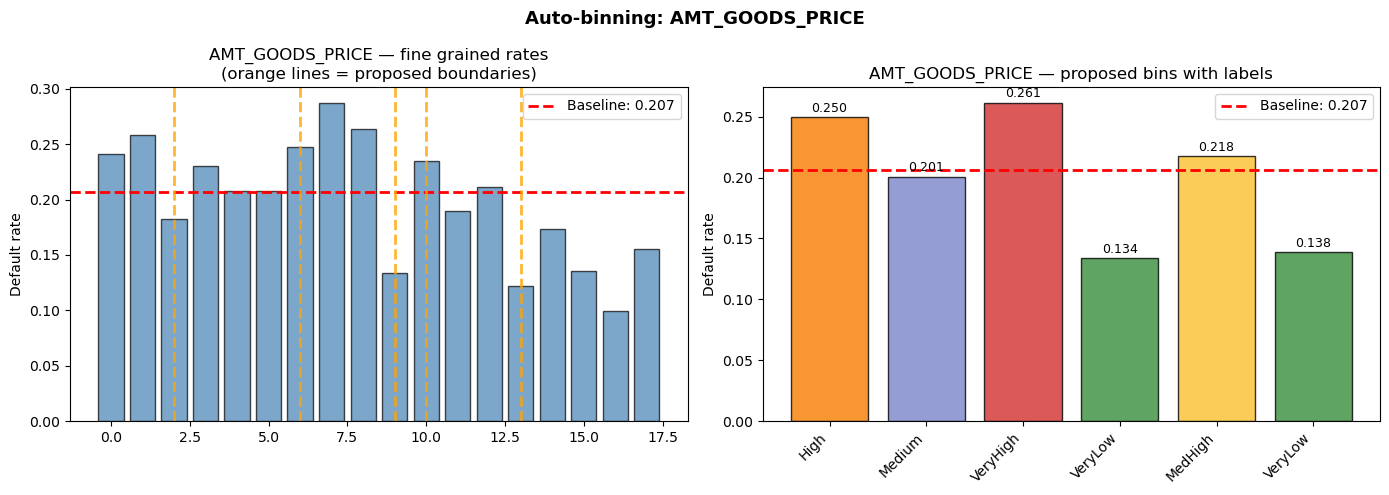


AUTO-BINNING: DEF_30_CNT_SOCIAL_CIRCLE

  Natural breakpoints found at: [2.0]

  Recommended binning for DEF_30_CNT_SOCIAL_CIRCLE:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →          1]   0.206  Medium
  (         1 →         34]   0.239  High

  Spread:  3.3pp
  Verdict: Weak     — marginal value, only add if CPT cost is low

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(1.0), np.float64(34.0)]
  labels= ['Medium', 'High']


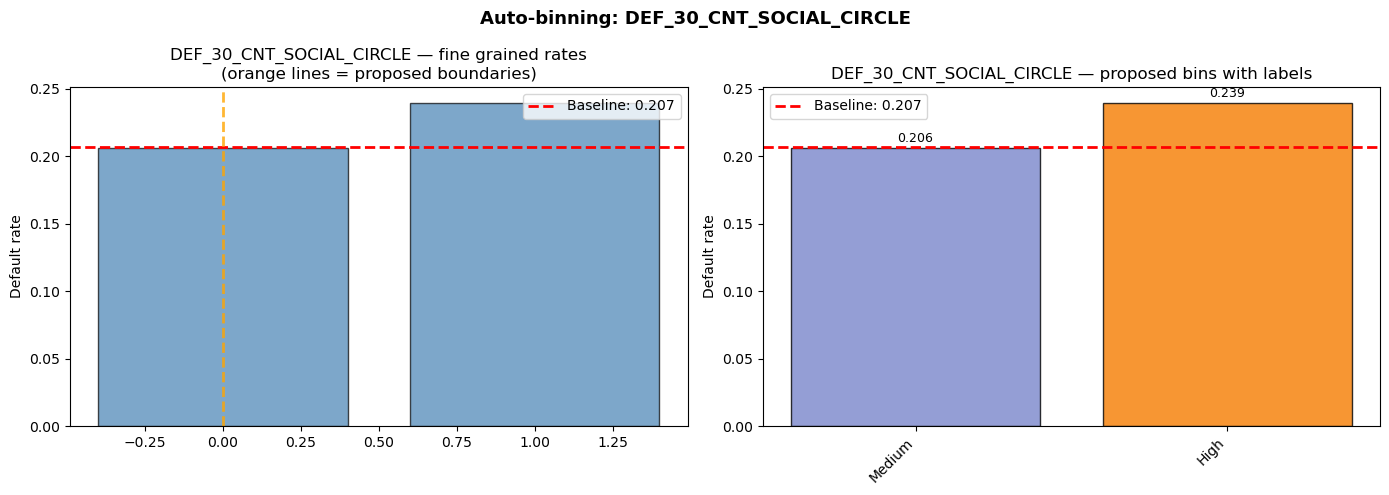


AUTO-BINNING: DEF_60_CNT_SOCIAL_CIRCLE

  Natural breakpoints found at: [2.0]

  Recommended binning for DEF_60_CNT_SOCIAL_CIRCLE:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →          1]   0.206  Medium
  (         1 →         24]   0.245  High

  Spread:  3.9pp
  Verdict: Weak     — marginal value, only add if CPT cost is low

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(1.0), np.float64(24.0)]
  labels= ['Medium', 'High']


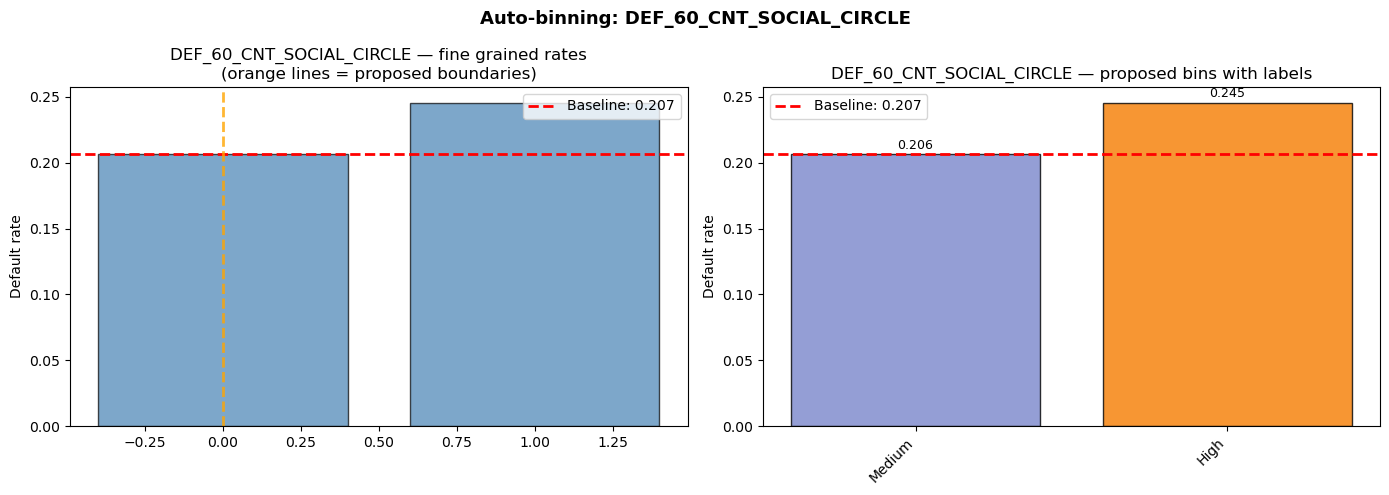


AUTO-BINNING: AMT_REQ_CREDIT_BUREAU_MON

  Natural breakpoints found at: [2.0]

  Recommended binning for AMT_REQ_CREDIT_BUREAU_MON:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →          1]   0.210  Medium
  (         1 →         27]   0.065  VeryLow

  Spread:  14.5pp
  Verdict: Strong   — worth adding as direct LoanOutcome parent

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(1.0), np.float64(27.0)]
  labels= ['Medium', 'VeryLow']


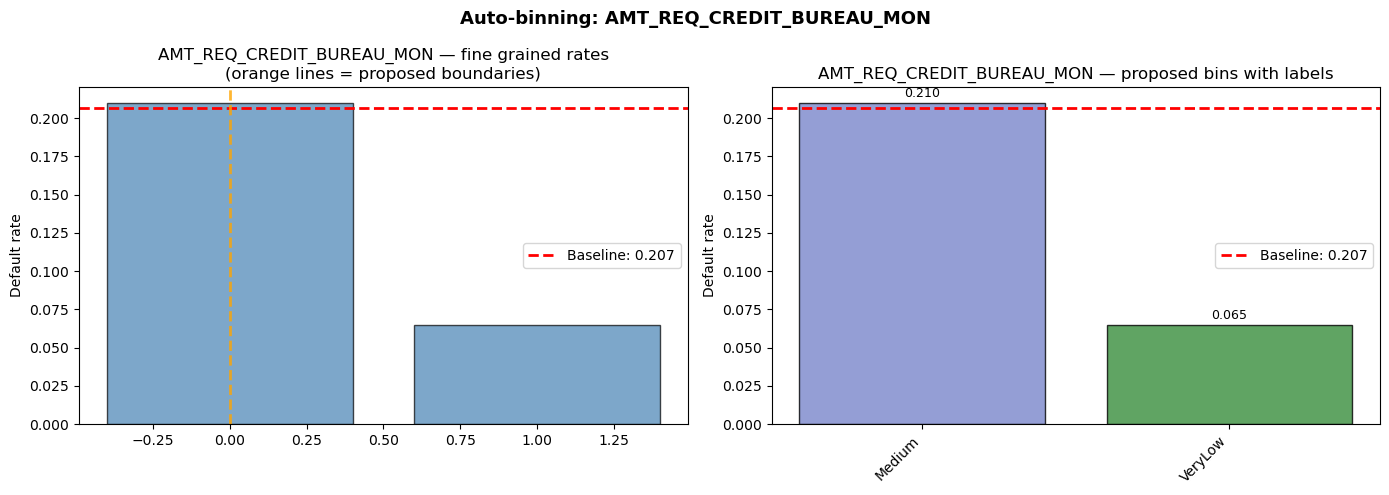


AUTO-BINNING: AMT_REQ_CREDIT_BUREAU_QRT

  Natural breakpoints found at: [2.0, 3.0]

  Recommended binning for AMT_REQ_CREDIT_BUREAU_QRT:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →          1]   0.202  Medium
  (         1 →          2]   0.241  High
  (         2 →        261]   0.266  VeryHigh

  Spread:  6.4pp
  Verdict: Moderate — worth rebinning or adding as supporting node

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(261.0)]
  labels= ['Medium', 'High', 'VeryHigh']


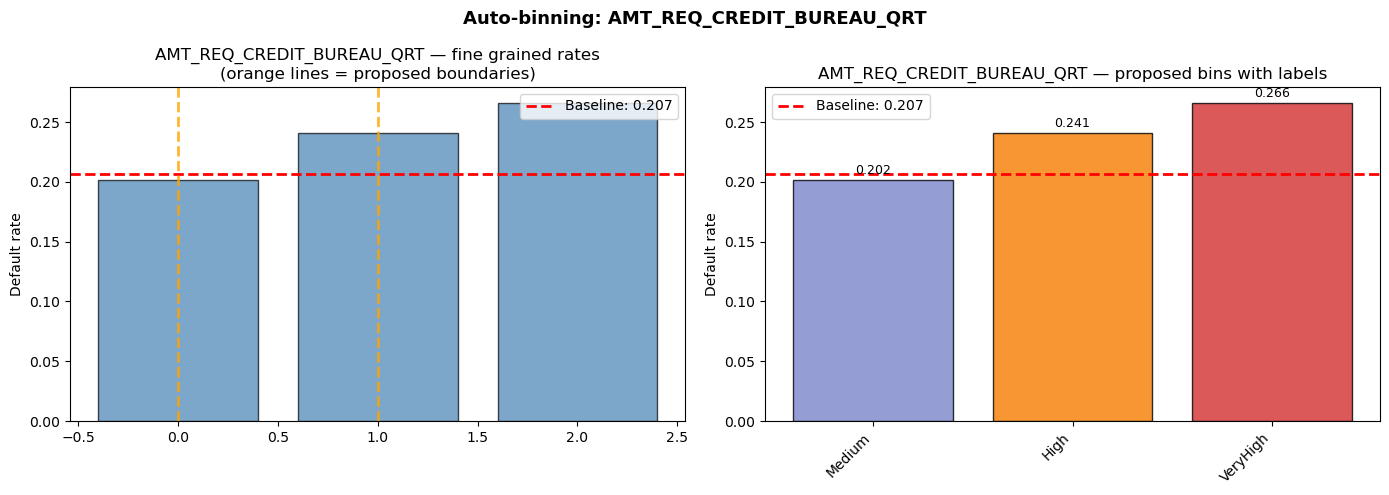


AUTO-BINNING: on_time_rate

  Natural breakpoints found at: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

  Recommended binning for on_time_rate:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →          1]   0.230  MedHigh
  (         1 →          1]   0.220  MedHigh
  (         1 →          1]   0.209  Medium
  (         1 →          1]   0.219  MedHigh
  (         1 →          1]   0.203  Medium

  Spread:  2.7pp
  Verdict: Skip     — noise level, not worth adding

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(0.68), np.float64(0.95), np.float64(0.97), np.float64(0.98), np.float64(1.0)]
  labels= ['MedHigh', 'MedHigh', 'Medium', 'MedHigh', 'Medium']


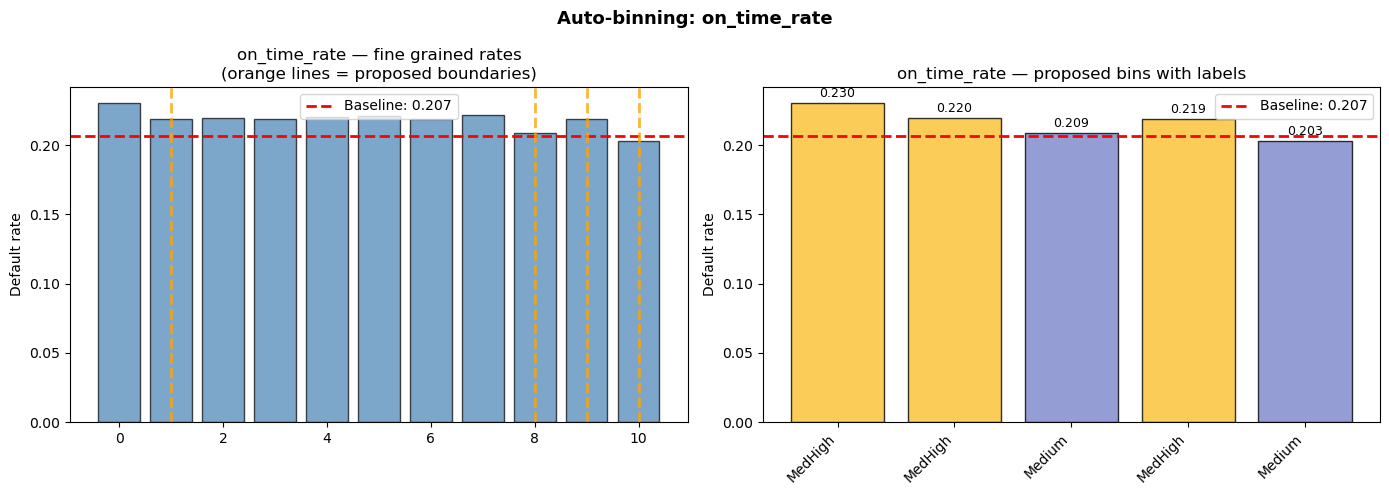


AUTO-BINNING: avg_utilization

  Natural breakpoints found at: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]

  Recommended binning for avg_utilization:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (        -0 →          0]   0.231  MedHigh
  (         0 →          1]   0.218  MedHigh
  (         1 →          1]   0.242  High
  (         1 →          1]   0.260  VeryHigh
  (         1 →          1]   0.278  VeryHigh
  (         1 →          2]   0.304  VeryHigh

  Spread:  8.6pp
  Verdict: Moderate — worth rebinning or adding as supporting node

  pd.cut code:
  bins  = [np.float64(-0.07), np.float64(0.06), np.float64(0.54), np.float64(0.72), np.float64(0.82), np.float64(0.91), np.float64(2.14)]
  labels= ['MedHigh', 'MedHigh', 'High', 'VeryHigh', 'VeryHigh', 'VeryHigh']


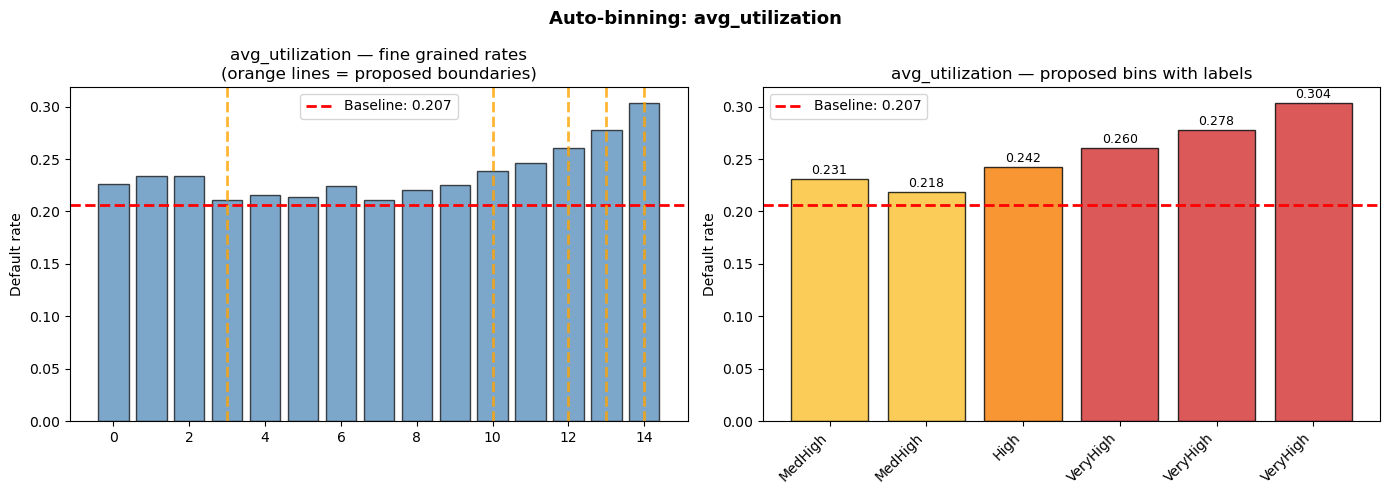


AUTO-BINNING: max_days_overdue

  Natural breakpoints found at: []

  Recommended binning for max_days_overdue:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →       2792]   0.205  Medium

  Spread:  0.0pp
  Verdict: Drop     — confirmed no signal

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(2792.0)]
  labels= ['Medium']


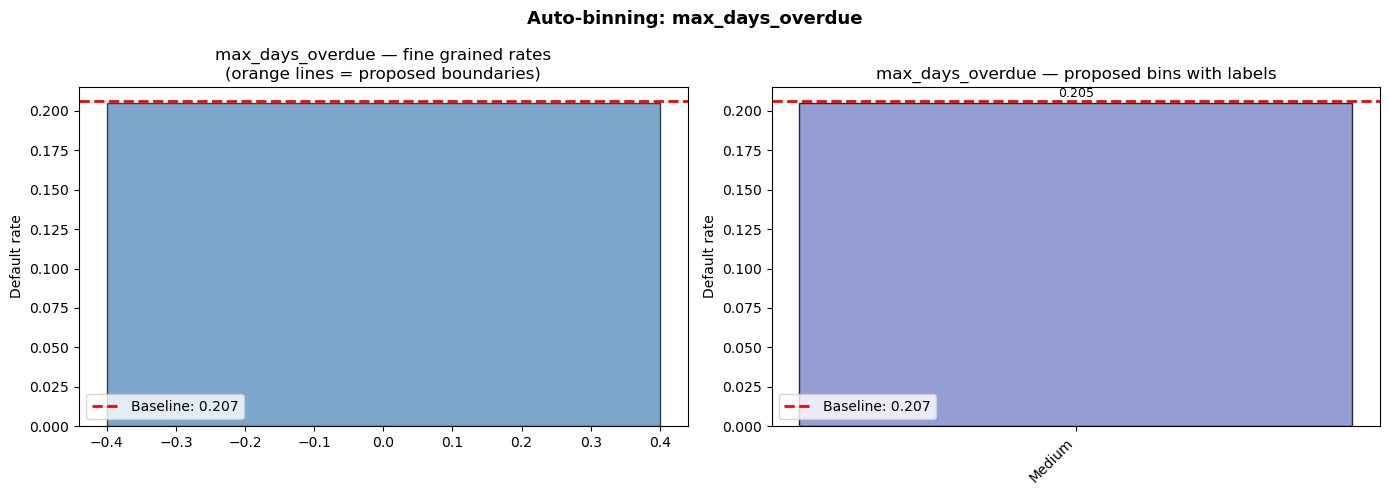


AUTO-BINNING: prior_refused

  Natural breakpoints found at: [2.0]

  Recommended binning for prior_refused:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →          1]   0.202  Medium
  (         1 →          2]   0.238  High
  (         2 →          3]   0.251  High
  (         3 →          4]   0.263  VeryHigh
  (         4 →         68]   0.279  VeryHigh

  Spread:  7.7pp
  Verdict: Moderate — worth rebinning or adding as supporting node

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(68.0)]
  labels= ['Medium', 'High', 'High', 'VeryHigh', 'VeryHigh']


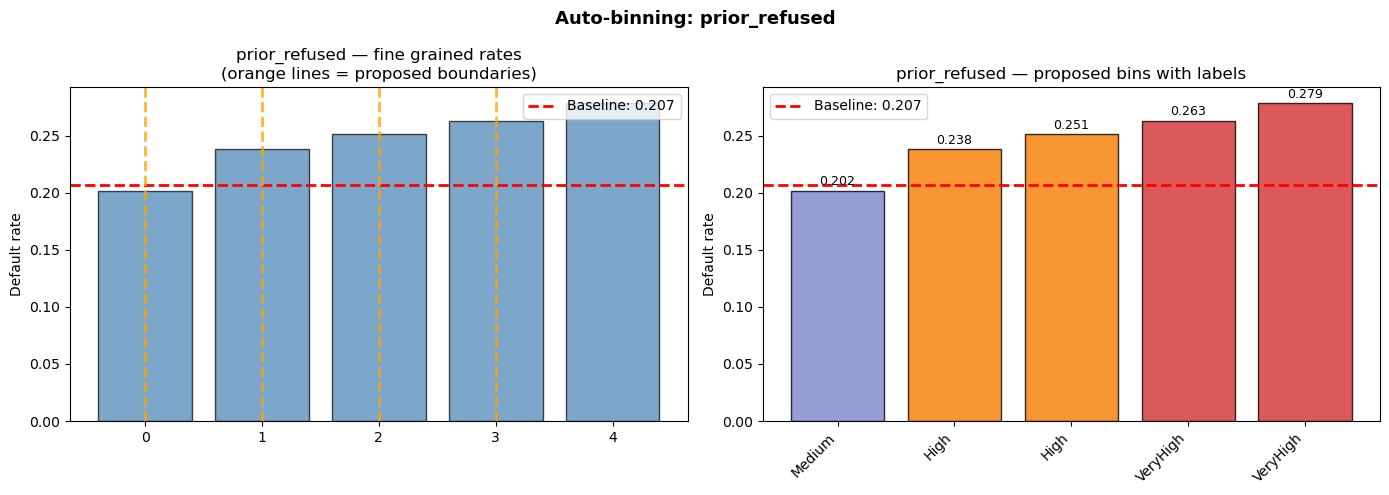


AUTO-BINNING: active_credits

  Natural breakpoints found at: [2.0, 6.0]

  Recommended binning for active_credits:
  Bin range                          Rate  Label
  ───────────────────────────────────────────────────────
  (         0 →          2]   0.196  MedLow
  (         2 →          3]   0.209  Medium
  (         3 →          4]   0.225  MedHigh
  (         4 →          5]   0.239  High
  (         5 →         32]   0.262  VeryHigh

  Spread:  6.5pp
  Verdict: Moderate — worth rebinning or adding as supporting node

  pd.cut code:
  bins  = [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(32.0)]
  labels= ['MedLow', 'Medium', 'MedHigh', 'High', 'VeryHigh']


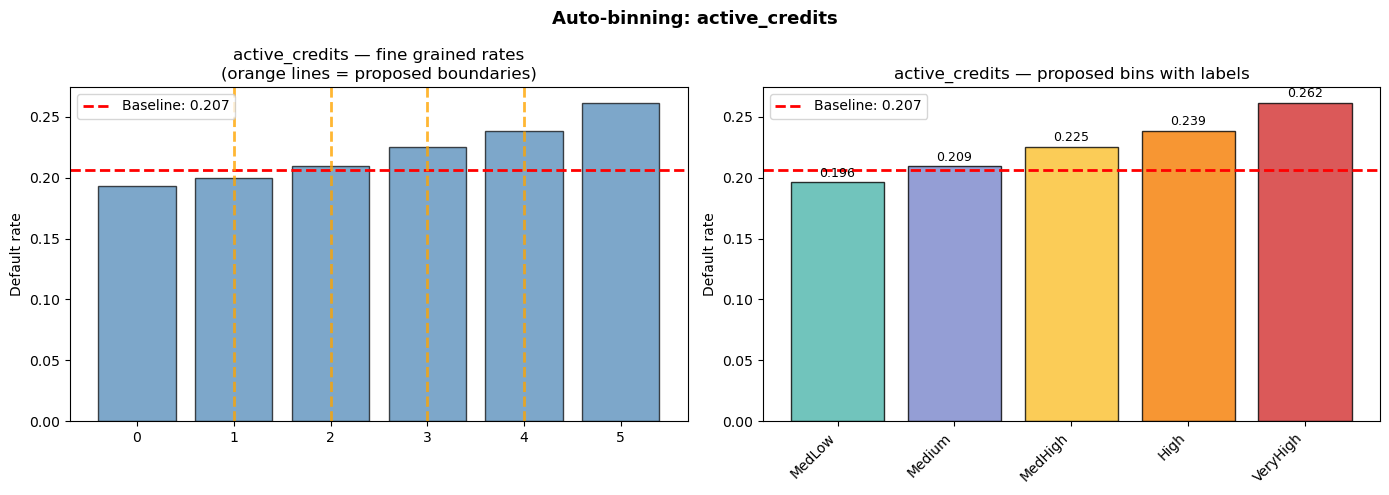

In [94]:
labeled = raw_df[['SK_ID_CURR','LoanOutcome']].dropna(subset=['LoanOutcome']).copy()
baseline = labeled['LoanOutcome'].eq('Defaulted').mean()

auto_bin_results = {}
for col in continuous:
    if col in raw_df.columns:
        print(f"\n{'='*60}")
        print(f"AUTO-BINNING: {col}")
        print(f"{'='*60}")
        result = auto_bin(
            raw_df, col, labeled,
            baseline    = baseline,
            min_count   = 1000,
            max_bins    = 6,
            n_quantiles = 20
        )
        if result is not None:
            auto_bin_results[col] = result

In [96]:
print('summary')
print(df.isnull().sum())
print('raw')
print(raw_df.isnull().sum())

summary
IncomeType           0
OccupationType       0
IncomeBracket        0
LoanOutcome          0
ExtSource1Risk       0
ExtSource2Risk       0
ExtSource3Risk       0
PaymentHistory       0
PriorLoanApproved    0
PrevRejected         0
CreditUtilization    0
DPD                  0
ContractStatus       0
DaysOverdue          0
MaxOverdue           0
DebtLoad             0
CreditProlonged      0
ActiveCredits        0
dtype: int64
raw
SK_ID_CURR                           0
TARGET                           48744
NAME_CONTRACT_TYPE                   0
CODE_GENDER                          0
FLAG_OWN_CAR                         0
FLAG_OWN_REALTY                      0
CNT_CHILDREN                         0
AMT_INCOME_TOTAL                     0
AMT_CREDIT                           0
AMT_ANNUITY                         36
AMT_GOODS_PRICE                    278
NAME_TYPE_SUITE                   2203
NAME_INCOME_TYPE                     0
NAME_EDUCATION_TYPE                  0
NAME_FAMILY_STA

In [ ]:
import 